# Analysis of diversity hotspots across Mtb genome

### Import Statements

In [1]:
import numpy as np
import pandas as pd
#import vcf
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import scipy.stats

%matplotlib inline

In [2]:
from scipy import stats


In [3]:
import bioframe as bf

In [4]:
import json

In [5]:
from Bio import SeqIO


In [6]:
from pycirclize import Circos


In [7]:
from matplotlib.ticker import FuncFormatter

# Function to convert base pairs to megabases
def bp_to_mb(x, pos):
    return f'{x * 1e-6:.1f}'

#### Pandas Viewing Settings

In [8]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [9]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch


In [10]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [11]:
# Define matplotlib plot style from config file
plt.style.use('../mgm.v1.mplstyle')

# Import custom utils functions

In [12]:
%load_ext autoreload
%autoreload 2

#from gcutils.general import parse_PAFtools_VarTSV, label_DF_ByOvrLapGenes, label_PAF_DF_ByOvrLapGenes'

from gcutils.general import check_overlap_with_gene_group 

# Parse `Mtb151CI` Isolate Metadata

In [13]:
Repo_DataDir = "../../Data"
InputAsmPath_Dir = f"{Repo_DataDir}/231121.InputAsmTSVs.MtbSetV3.151CI"

MtbSetV3_151CI_InputAsmPATHs_TSV = f"{InputAsmPath_Dir}/231121.MtbSetV3.151CI.HybridAndSRAsm.FAPATHs.V1.tsv"
MtbSetV3_151CI_AsmSumm_TSV = f"{InputAsmPath_Dir}/231121.MtbSetV3.151CI.HybridAsm.AsmSummary.V2.tsv"


### Reading in "WGA151CI_AsmSummary_DF"

In [14]:
WGA151CI_AsmSummary_DF = pd.read_csv(MtbSetV3_151CI_AsmSumm_TSV, sep = "\t")

SampleIDs_151CI_SOI = list( WGA151CI_AsmSummary_DF["SampleID"].values )
WGA151CI_SampleIDs = SampleIDs_151CI_SOI
WGA151CI_AsmSummary_DF.shape


(151, 7)

#### Create SampleID Mapping Dicts

In [15]:
WGA151CI_ID_To_PrimLineage_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'PrimaryLineage']].values)
WGA151CI_ID_To_SubLineage_Dict = dict( WGA151CI_AsmSummary_DF[["SampleID", "Lineage"]].values)
WGA151CI_ID_To_Dataset_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'Dataset_Tag']].values)  


#### Parse Assembly to FASTA DF

In [16]:
WGA151CI_Asm_Path_DF = pd.read_csv(MtbSetV3_151CI_InputAsmPATHs_TSV, sep = "\t")
ID_To_CompleteAsm_Dict = dict(WGA151CI_Asm_Path_DF[['SampleID', 'Genome_ASM_PATH']].values)  
WGA151CI_Asm_Path_DF.shape

(151, 4)

In [17]:
WGA151CI_Asm_Path_DF.head(2)

,SampleID,Dataset_Tag,Genome_ASM_PATH,ShortRead_Genome_ASM_PATH
0,N0072,ChinerOms_2019,/n/data1/hms/dbmi/farhat/mm774/Projects/231121...,/n/data1/hms/dbmi/farhat/mm774/Projects/231121...
1,N0153,ChinerOms_2019,/n/data1/hms/dbmi/farhat/mm774/Projects/231121...,/n/data1/hms/dbmi/farhat/mm774/Projects/231121...


# Import/parse processed H37rv genome annotations

In [18]:
RepoRef_Dir = "../../References"

AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir = f"{RepoRef_Dir}/201027_H37rv_AnnotatedGenes_And_IntergenicRegions"
# H37Rv_GenomeAnnotations_Genes_TSV = f"{AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir}/H37Rv_GenomeAnnotations.Genes.tsv"
H37Rv_GenomeAnnotations_Genes_V2_TSV = f"{AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir}/H37Rv_GenomeAnnotations.Genes.V2.tsv"


## H37Rv Gene Annotations TSV
H37Rv_GenomeAnno_Genes_DF = pd.read_csv(H37Rv_GenomeAnnotations_Genes_V2_TSV, sep = "\t")
#H37Rv_GeneInfo_Subset_DF = H37Rv_GenomeAnno_Genes_DF[["H37rv_GeneID", "Symbol", "Feature", "Functional_Category", "Is_Pseudogene", "Product", "PEandPPE_Subfamily", "ExcludedGroup_Category"]]

RvID_To_Symbol_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['H37rv_GeneID', 'Symbol']].values)
Symbol_To_RvID_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['Symbol', 'H37rv_GeneID']].values)
Symbol_To_FuncCat_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['Symbol', 'Functional_Category']].values)

ESX_Genes_List_TSV = f"{RepoRef_Dir}/190927_H37rv_ListOf_ESXgenes.tsv"
Esx_Genes_DF = pd.read_csv(ESX_Genes_List_TSV, sep = '\t')

In [19]:
H37Rv_GenomeAnno_Genes_DF.head(1)

,Chrom,Start,End,Strand,H37rv_GeneID,Symbol,Feature,Functional_Category,Is_Pseudogene,Product,PEandPPE_Subfamily,ExcludedGroup_Category,Gene_Cat_V2,Middle,Length
0,NC_000962.3,0,1524,+,Rv0001,dnaA,CDS,information pathways,No,Chromosomal replication initiator protein DnaA,NaN,NotExcluded,information pathways,762.0,1524


### Define paths to H37Rv genome masking schemes

In [20]:
RepoRef_Dir = "../../References"

MaskingSchemes_Dir = f"{RepoRef_Dir}/Mtb_H37Rv_MaskingSchemes"
PLC_Scheme_BED = f"{MaskingSchemes_Dir}/201027_Mtb_H37rv_pLC_Regions_CoscollaExcludedGenes.bed"


### Define relevant H37Rv gene lists for analysis (PE/PPE, Esx, 13E12 gene)

In [21]:
ListOf_Esx_Symbols = list(Esx_Genes_DF["symbol"].values)
ListOf_Esx_RvIDs = list(Esx_Genes_DF["gene_id"].values)

In [22]:
listOf_PEPPE_Symbols = list( H37Rv_GenomeAnno_Genes_DF.query(" Functional_Category == 'PE/PPE' ")["Symbol"].values )
listOf_PEPPE_RvIDs = list( H37Rv_GenomeAnno_Genes_DF.query(" Functional_Category == 'PE/PPE' ")["H37rv_GeneID"].values )

In [23]:
listOf_13E12_Region_RvIDs = ["Rv0094c", "Rv0095c", "Rv0393", "Rv1572c", "Rv1572c", "Rv1128c", "Rv1148c", "Rv1587c", "Rv1588c", "Rv1702c", "Rv1945", "Rv2100", "Rv3466", "Rv3467"]  


### Read in annotated windows of the H37Rv genome

In [24]:
RepoRef_Dir = "../../References"

H37Rv_Windows_Dir = f"{RepoRef_Dir}/H37Rv_GenomeWindows"

H37Rv_1kb_Win_Anno_TSV = f"{H37Rv_Windows_Dir}/H37Rv.1000bp.Windows.Anno.tsv"

H37Rv_1kb_Win_DF = pd.read_csv(H37Rv_1kb_Win_Anno_TSV, sep = "\t")
# Rv_1kb_Window_Start_To_Genes_Dict = dict(H37Rv_1kb_Win_DF[['start', 'Overlap_Genes']].values)


In [25]:
H37Rv_1kb_Win_DF.head(1)

,Chrom,Start,End,Overlap_Genes,Middle
0,NC_000962.3,0,1000,dnaA,500.0


### Define paths to H37Rv genome masking schemes

In [26]:
RepoRef_Dir = "../../References"

MaskingSchemes_Dir = f"{RepoRef_Dir}/Mtb_H37Rv_MaskingSchemes"
PLC_Scheme_BED = f"{MaskingSchemes_Dir}/201027_Mtb_H37rv_pLC_Regions_CoscollaExcludedGenes.bed"

In [27]:
PLC_CoscollaMask_DF = pd.read_csv(PLC_Scheme_BED, sep = "\t", header=None)
PLC_CoscollaMask_DF.columns = ["Chrom", "Start", "End", "RvID", "Symbol", "FuncCat", "PEPPE_Family"]

listOf_PLC_GeneNames = list( PLC_CoscollaMask_DF["Symbol"].values )

PLC_CoscollaMask_DF.shape

(384, 7)

# Parse `LowComplexity` and `Low-Mappability` Regions of H37Rv

In [28]:
RepoRef_Dir = "../../References"
Rv_longdust_LCB_OutDir = f"{RepoRef_Dir}/H37Rv_Longdust_LowComplexityRegions"
Rv_LowPupMap_OutDir = f"{RepoRef_Dir}/H37Rv_MappabilityAnalysis_K50E4"

Rv_LowPupmap_K50E4_TSV = f"{Rv_LowPupMap_OutDir}/H37Rv.LowPileupMap.Below1.K50_E4.tsv"
Rv_LowComplexityRegions_TSV = f"{Rv_longdust_LCB_OutDir}/H37Rv.longdust.LCR.relaxedshorter.tsv"


In [29]:
Rv_LowPmap_DF = pd.read_csv(Rv_LowPupmap_K50E4_TSV, sep ="\t")
Rv_LowPmap_DF.shape

(1092, 5)

In [30]:
Rv_LCRs_DF = pd.read_csv(Rv_LowComplexityRegions_TSV, sep ="\t")
Rv_LCRs_DF.shape

(231, 5)

In [31]:
Rv_LowPmap_DF["Length"].sum()

189147

In [32]:
Rv_LCRs_DF["Length"].sum()

127160

# Define Color Pallete `Mtb-H37Rv` Gene Categories 

In [33]:
all_categories = [ "PE/PPE", "REP13E12_Repeat", "esx", "conserved hypotheticals", "cell wall and cell processes",
                  "insertion seqs and phages",
                  "intermediary metabolism and respiration", "lipid metabolism", "information pathways",
                  "virulence, detoxification, adaptation", "regulatory proteins",
                   "stable RNAs",  "unknown",  ] 

Mtb_GeneCat_ColorDict = { 
    "PE/PPE" : "#1ABFAD", 
    "REP13E12_Repeat" : "#FC2A5D", 
    "esx" : "#4382BC", 
    "conserved hypotheticals" : "#F2B84A", 
    "cell wall and cell processes" : "#7D3E84", 
    "insertion seqs and phages": "#E16843", 
    "intermediary metabolism and respiration" : "#4F7942",  # Deep green
    "lipid metabolism" : "#B07C2E",  # Warm brownish-orange
    "information pathways": "#5698C4",  # Soft blue
    "virulence, detoxification, adaptation": "#B0338E",  # Magenta-purple
    "regulatory proteins": "#A42CD6",  # Vivid violet
    "stable RNAs": "#5C5C5C",  # Neutral dark gray
    "unknown": "#999999",  # Lighter gray for unknown
}

Mtb_GeneCat_ColorPallete =  [Mtb_GeneCat_ColorDict[cat] for cat in all_categories] 

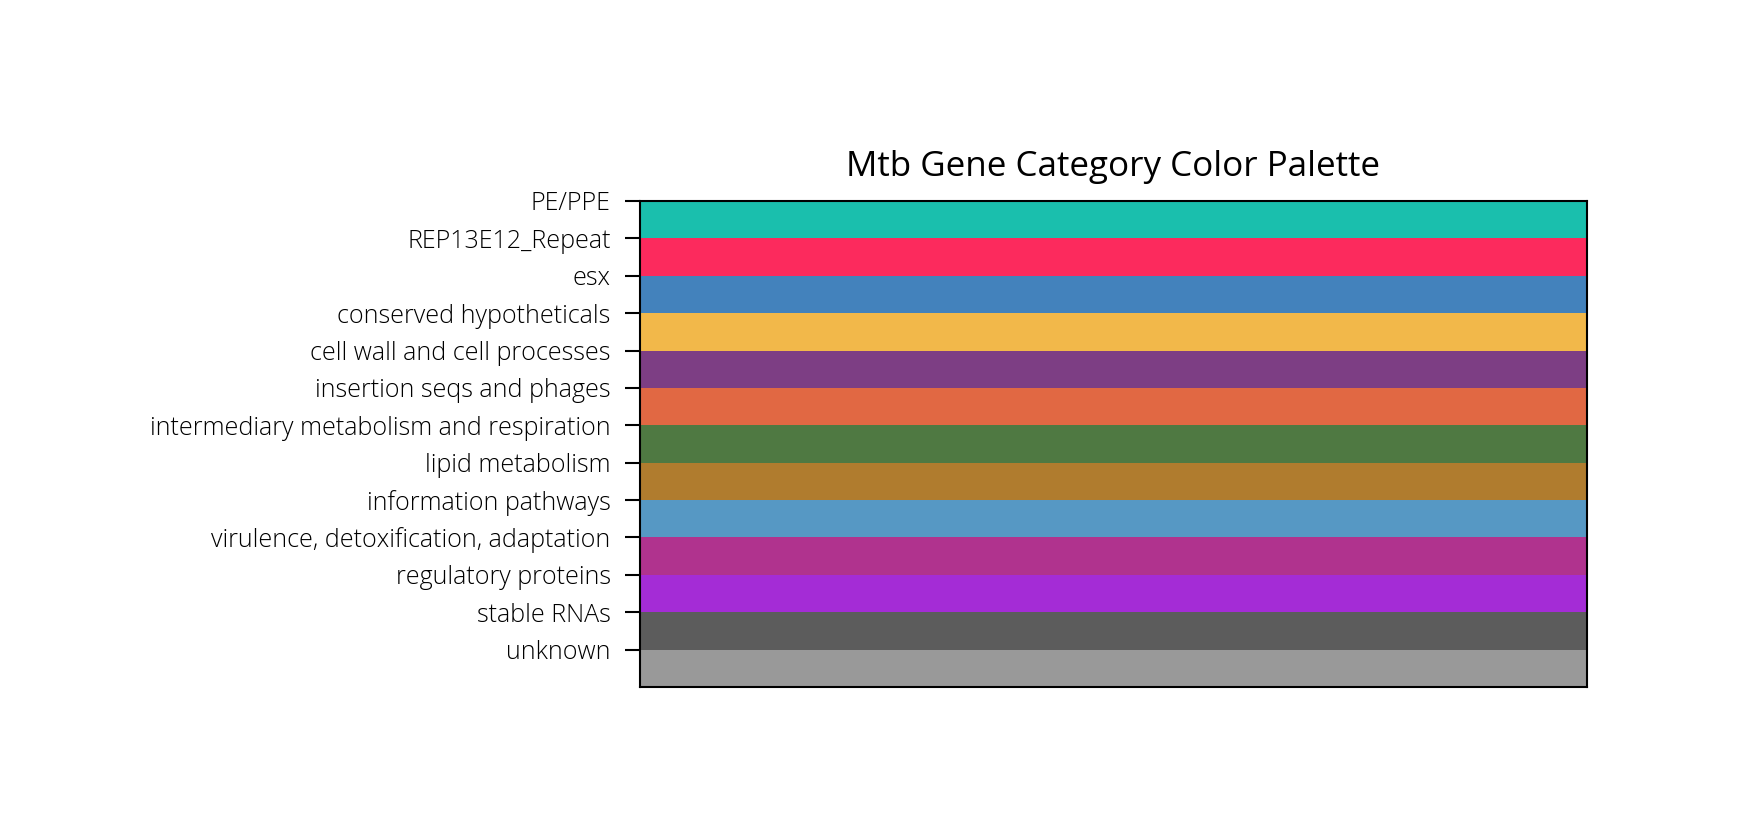

In [34]:
# Plot the colors
fig, ax = plt.subplots(figsize=(5, 2))
ax.set_xlim(0, 1)
ax.set_ylim(0, len(Mtb_GeneCat_ColorDict))
ax.set_xticks([])
ax.set_yticks(range(len(Mtb_GeneCat_ColorDict)))
ax.set_yticklabels(Mtb_GeneCat_ColorDict.keys(), fontsize=6)

for i, (category, color) in enumerate(Mtb_GeneCat_ColorDict.items()):
    ax.add_patch(plt.Rectangle((0, i), 1, 1, color=color))

plt.gca().invert_yaxis()
plt.title("Mtb Gene Category Color Palette")
plt.show()

# Parse in H37Rv Homology-Map Results (k19w19)

### Define all HmMap file paths

In [35]:
#Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V9"
Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10"

H37_Rv_MM2_HomologyMapping_Dir = f"{Main_Project_Dir}/250901.H37Rv.HomologyMapping.k19w19.ProcessedData.V2"

# Define paths to output TSVS

### Homologous regions (MERGED)
RvHmMap_Merged_ParaRegions_TSV  = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.MergedRegions.ParalogousRegions.k19w19.tsv"
RvHmMap_Merged_LocalRepeats_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.MergedRegions.LocalRepeats.k19w19.tsv"

### Homology map (pairwise alignments)
RvHmMap_Aln_All_TSV           = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.All.tsv"
RvHmMap_Aln_PRs_NoOverlap_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.NoOverlap.tsv"
RvHmMap_Aln_LRs_WiOverlap_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.WiOverlap.tsv"

RvHmMap_Aln_PRs_NoOverlap_Clustered_TSV     = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.NoOverlap.Clustered.tsv"
RvHmMap_Aln_LRs_WiOverlap_Clustered_TSV     = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.OnlyOverlap.Clustered.tsv"

### Variants from the homology map alignments
RvHmMap_Var_TSV      = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.tsv"
RvHmMap_Var_SNPs_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.snps.tsv"


### Parse in HmRegions (`Paralogous_Regions` and `Local_Repeats`)

In [36]:
HmMapRegs_ParaRegs_k19w19_DF = pd.read_csv(RvHmMap_Merged_ParaRegions_TSV,
                                    sep="\t")
#HmMapRegs_ParaRegs_k19w19_DF["Overlap_Genes"] = HmMapRegs_ParaRegs_k19w19_DF["Overlap_Genes"].fillna("_")

HmMapRegs_ParaRegs_k19w19_DF.shape

(200, 15)

In [37]:
HmMapRegs_LocalRepeats_k19w19_DF = pd.read_csv(RvHmMap_Merged_LocalRepeats_TSV, 
                                        sep="\t")

#HmMapRegs_LocalRepeats_k19w19_DF["Overlap_Genes"] = HmMapRegs_LocalRepeats_k19w19_DF["Overlap_Genes"].fillna("_")

HmMapRegs_LocalRepeats_k19w19_DF.shape

(50, 13)

In [38]:
HmMapRegs_All_LRsPRs_K19w19_DF = pd.concat([HmMapRegs_ParaRegs_k19w19_DF,
                                            HmMapRegs_LocalRepeats_k19w19_DF])

HmMapRegs_All_LRsPRs_K19w19_DF.shape

(250, 15)

In [39]:
HmMapRegs_ParaRegs_k19w19_DF.head(2)

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000,0,PR_Set_1
1,1,NC_000962.3,80623,82664,81643.5,2041,"Rv0072,Rv0073",0,1,1,1,1,PR_HmRegion_001,0,PR_Set_2


#### Peak at head of each HmMap Regions DFs

In [40]:
HmMapRegs_ParaRegs_k19w19_DF.head()

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000,0,PR_Set_1
1,1,NC_000962.3,80623,82664,81643.5,2041,"Rv0072,Rv0073",0,1,1,1,1,PR_HmRegion_001,0,PR_Set_2
2,2,NC_000962.3,103705,105130,104417.5,1425,"Rv0094c,Rv0095c",0,2,2,2,2,PR_HmRegion_002,0,PR_Set_3
3,3,NC_000962.3,149571,149808,149689.5,237,PE_PGRS2,0,1,1,1,3,PR_HmRegion_003,0,PR_Set_4
4,4,NC_000962.3,177203,177447,177325.0,244,_,0,1,1,1,4,PR_HmRegion_004,0,PR_Set_5


In [41]:
HmMapRegs_LocalRepeats_k19w19_DF.head()

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID
0,0,NC_000962.3,333811,335879,334845.0,2068,PE_PGRS3,0,1,1,1,0,LR_HmRegion_000
1,1,NC_000962.3,366430,375121,370775.5,8691,"PPE5,PPE6",0,6,6,6,1,LR_HmRegion_001
2,2,NC_000962.3,424011,432951,428481.0,8940,"hspR,PPE7,PPE8",0,5,4,4,2,LR_HmRegion_002
3,3,NC_000962.3,566288,580814,573551.0,14526,"hbhA,Rv0476,Rv0477,deoC,Rv0479c,Rv0480c,Rv0481...",0,4,2,1,3,LR_HmRegion_003
4,4,NC_000962.3,631298,631436,631367.0,138,Rv0538,0,2,2,2,4,LR_HmRegion_004


### Parse in homology-map DFs (pairwise alignments between all homologous regions)

In [42]:
HmMap_Aln_k19w19_DF = pd.read_csv(RvHmMap_Aln_All_TSV,
                           sep="\t")
HmMap_Aln_k19w19_DF.shape

(776, 25)

In [43]:
HmMap_Aln_k19w19_NoOverlap_DF = pd.read_csv(RvHmMap_Aln_PRs_NoOverlap_Clustered_TSV,
                                     sep="\t")
HmMap_Aln_k19w19_NoOverlap_DF.shape

(640, 38)

In [44]:
HmMap_Aln_k19w19_LocalRepeat_DF = pd.read_csv(RvHmMap_Aln_LRs_WiOverlap_Clustered_TSV,
                                              sep="\t")
HmMap_Aln_k19w19_LocalRepeat_DF.shape

(136, 35)

In [45]:
HmMap_Aln_PR_ExactCopy_DF = HmMap_Aln_k19w19_NoOverlap_DF.query("SeqID == 1.0")
print(HmMap_Aln_PR_ExactCopy_DF.shape)

(255, 38)


In [46]:
HmMap_Aln_PR_NoPerfAln_DF = HmMap_Aln_k19w19_NoOverlap_DF.query("SeqID != 1.0")
print(HmMap_Aln_PR_NoPerfAln_DF.shape)

(385, 38)


In [47]:

HmMap_Aln_PR_MaxSeqID99_DF = HmMap_Aln_k19w19_NoOverlap_DF.query("SeqID <= 0.99")
print(HmMap_Aln_PR_MaxSeqID99_DF.shape)

(331, 38)


### Parse in HomologyMap Alignment Variants DFs

In [48]:
Mtb_HM_Var_DF = pd.read_csv(RvHmMap_Var_TSV, sep="\t")
Mtb_HM_Var_SNPs_DF = pd.read_csv(RvHmMap_Var_SNPs_TSV, sep="\t")

In [49]:
# Build trimmed + unique HM SNPs DF
UnqSNPs_TarCol = ['Query_Name', 'Query_Start', 'Query_End', 'Ref', 'Alt', 'SNP']

HM_Var_SNPs_TrimUnq_DF = Mtb_HM_Var_SNPs_DF[UnqSNPs_TarCol].drop_duplicates()
HM_Var_SNPs_TrimUnq_DF.shape

(52699, 6)

In [50]:
Mtb_HM_Var_DF.shape

(79508, 14)

In [51]:
Mtb_HM_Var_SNPs_DF.shape

(65617, 14)

# Parse processed results

In [52]:
AnalysisName = "250201.WGA151CI.V10"

Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10"

Target_Output_Dir = f"{Main_Project_Dir}/{AnalysisName}"

input_SampleNames = SampleIDs_151CI_SOI


## Read back in NucDiv DF (1kb, no regions filtering)

In [53]:
VCFT_NucDiv_Dir = f"{Target_Output_Dir}/VCFtools_SNV_NucDiv_AcrossH37Rv"

Pickle_PATH_WGA_NucDiv_PI_Dict = VCFT_NucDiv_Dir + f"/{AnalysisName}.SNVs.NucDiv.DictOfResults.pickle"   
#NucDiv_NoFilt_1kb_TSV_PATH = f"{VCFT_NucDiv_Dir}/WGA.SNVs.NucDiv.1000bp.ALL.tsv"
NucDiv_NoFilt_1kb_TSV_PATH = f"{VCFT_NucDiv_Dir}/WGA.SNVs.NucDiv.1000bp.ALL.Anno.tsv"


### Parse pickle of NucDiv stats

In [54]:
with open(Pickle_PATH_WGA_NucDiv_PI_Dict, "rb") as f: NucDiv_PI_Dict = pickle.load(f)
NucDiv_PI_Dict.keys()

dict_keys([('ALL', 1000)])

### parse 1-kb NucDiv DF

In [55]:
# Read in TSV
WGA_NucDiv_PI_1kb_DF = pd.read_csv(NucDiv_NoFilt_1kb_TSV_PATH, sep = "\t")

# # Calculate mean, median, standard deviation, and Median Absolute Deviation
median_1kb_PI = WGA_NucDiv_PI_1kb_DF['NucDiv_kb'].median()
mean_1kb_PI = WGA_NucDiv_PI_1kb_DF['NucDiv_kb'].mean()
std_1kb_PI = WGA_NucDiv_PI_1kb_DF['NucDiv_kb'].std()
MAD_1kb_PI = np.median(np.abs(WGA_NucDiv_PI_1kb_DF['NucDiv_kb'] - median_1kb_PI))

# # Define outliers using modified Z-score procedure (Uses median instead of mean to ID outliers)

WGA_NucDiv_PI_1kb_DF['NucDiv_ModZ'] = 0.6745 * (WGA_NucDiv_PI_1kb_DF['NucDiv_kb'] - median_1kb_PI) / MAD_1kb_PI
WGA_NucDiv_PI_1kb_DF['IsNucDivHotspot'] = np.where(WGA_NucDiv_PI_1kb_DF['NucDiv_ModZ'] > 10, True, False)


# WGA_NucDiv_PI_1kb_DF['NucDiv_Z'] = (WGA_NucDiv_PI_1kb_DF['NucDiv'] - mean_1kb_PI) / std_1kb_PI

# #WGA_NucDiv_PI_1kb_DF['IsNucDivHotspot'] = np.where(WGA_NucDiv_PI_1kb_DF['NucDiv'] > 0.0025, True, False)
#WGA_NucDiv_PI_1kb_DF['IsNucDivHotspot'] = np.where(WGA_NucDiv_PI_1kb_DF['NucDiv_ModZ'] > 10, True, False)


In [56]:
WGA_NucDiv_PI_1kb_DF.head(1)

,Chrom,Start,End,NucDiv,OverlapGenes,Middle,NucDiv_kb,NucDiv_Z,NucDiv_ModZ,IsNucDivHotspot
0,NC_000962.3,0,1000,0.000218,dnaA,500.0,0.217905,-0.178778,0.127863,False


In [57]:
WGA_NucDiv_PI_1kb_DF['IsNucDivHotspot'].value_counts()

IsNucDivHotspot
False    4384
True       37
Name: count, dtype: int64

In [58]:
ModZ_10_NucDiv = (10 / 0.6745) * MAD_1kb_PI + median_1kb_PI
ModZ_10_NucDiv

2.2427835218680507

In [59]:
WGA_NucDiv_PI_1kb_DF.head(1)

,Chrom,Start,End,NucDiv,OverlapGenes,Middle,NucDiv_kb,NucDiv_Z,NucDiv_ModZ,IsNucDivHotspot
0,NC_000962.3,0,1000,0.000218,dnaA,500.0,0.217905,-0.178778,0.127863,False


### Label all windows of the genome by overlap of (PRs, LCRs, Low-Pmap, PLC Regions, etc)

In [60]:
NucDiv_CoordCols = ("Chrom", "Start", "End")
Mask_CoordCols = ("Chrom", "Start", "End")
HmAlnPAF_CoordCols = ("Query_Name", "Query_Start", "Query_End")


In [61]:
WGA_NucDiv_V2_DF = WGA_NucDiv_PI_1kb_DF.copy()

WGA_NucDiv_V2_DF = bf.count_overlaps(WGA_NucDiv_V2_DF,
                                     HmMap_Aln_k19w19_NoOverlap_DF, 
                                     cols1 = NucDiv_CoordCols,
                                     cols2 = HmAlnPAF_CoordCols ).rename(columns={'count': 'N_HmMapAln_PR_Ovrlap'})

WGA_NucDiv_V2_DF["OvrlapWi_HmMapAln_PR"] = np.where(WGA_NucDiv_V2_DF['N_HmMapAln_PR_Ovrlap'] > 0, 1, 0)


WGA_NucDiv_V2_DF = bf.count_overlaps(WGA_NucDiv_V2_DF,
                                     HmMap_Aln_k19w19_LocalRepeat_DF, 
                                     cols1 = NucDiv_CoordCols,
                                     cols2 = HmAlnPAF_CoordCols ).rename(columns={'count': 'N_HmMapAln_LR_Ovrlap'})


WGA_NucDiv_V2_DF["OvrlapWi_HmMapAln_LR"] = np.where(WGA_NucDiv_V2_DF['N_HmMapAln_LR_Ovrlap'] > 0, 1, 0)


WGA_NucDiv_V2_DF = bf.count_overlaps(WGA_NucDiv_V2_DF,
                                     Rv_LCRs_DF, 
                                     cols1 = NucDiv_CoordCols,
                                     cols2 = ('chrom', 'start', 'end') ).rename(columns={'count': 'N_LCR_Ovrlap'})

WGA_NucDiv_V2_DF["OvrlapWi_LowComplexityRegion"] = np.where(WGA_NucDiv_V2_DF['N_LCR_Ovrlap'] > 0, 1, 0)


WGA_NucDiv_V2_DF = bf.count_overlaps(WGA_NucDiv_V2_DF,
                                     Rv_LowPmap_DF, 
                                     cols1 = NucDiv_CoordCols,
                                     cols2 = ('chrom', 'start', 'end')).rename(columns={'count': 'N_LowPmap_Ovrlap'})

WGA_NucDiv_V2_DF["OvrlapWi_LowPmap"] = np.where(WGA_NucDiv_V2_DF['N_LowPmap_Ovrlap'] > 0, 1, 0)



#### Label NucDiv DF by whether a Masked Region from Coscolla-2015 (PLC) overlaps
WGA_NucDiv_V2_DF = bf.count_overlaps(WGA_NucDiv_V2_DF,
                                     PLC_CoscollaMask_DF,
                                     cols1 = NucDiv_CoordCols,
                                     cols2 = Mask_CoordCols ).rename(columns={'count': 'PLC_Mask_Count'} )

WGA_NucDiv_V2_DF["PLC_Mask_Ovrlap"] = np.where(WGA_NucDiv_V2_DF['PLC_Mask_Count'] > 0, 1, 0)


In [62]:
WGA_NucDiv_V2_DF.head()

,Chrom,Start,End,NucDiv,OverlapGenes,Middle,NucDiv_kb,NucDiv_Z,NucDiv_ModZ,IsNucDivHotspot,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,PLC_Mask_Count,PLC_Mask_Ovrlap
0,NC_000962.3,0,1000,0.000218,dnaA,500.0,0.217905,-0.178778,0.127863,False,0,0,0,0,0,0,0,0,0,0
1,NC_000962.3,1000,2000,0.000791,dnaA,1500.0,0.790654,0.829172,2.920256,False,0,0,0,0,0,0,0,0,0,0
2,NC_000962.3,2000,3000,0.000306,dnaN,2500.0,0.305560,-0.024519,0.555218,False,0,0,0,0,0,0,0,0,0,0
3,NC_000962.3,3000,4000,0.000221,"dnaN,recF",3500.0,0.221073,-0.173203,0.143308,False,0,0,0,0,0,0,0,0,0,0
4,NC_000962.3,4000,5000,0.000222,"recF,Rv0004",4500.0,0.222481,-0.170725,0.150173,False,0,0,0,0,0,0,0,0,0,0


### Create NucDiv summary DF with simplified columns

In [63]:
WGA_NucDiv_V2_DF.shape

(4421, 20)

In [64]:
WGA_NucDiv_V2_DF.columns

Index(['Chrom', 'Start', 'End', 'NucDiv', 'OverlapGenes', 'Middle', 'NucDiv_kb', 'NucDiv_Z', 'NucDiv_ModZ', 'IsNucDivHotspot', 'N_HmMapAln_PR_Ovrlap', 'OvrlapWi_HmMapAln_PR', 'N_HmMapAln_LR_Ovrlap', 'OvrlapWi_HmMapAln_LR', 'N_LCR_Ovrlap', 'OvrlapWi_LowComplexityRegion', 'N_LowPmap_Ovrlap', 'OvrlapWi_LowPmap', 'PLC_Mask_Count', 'PLC_Mask_Ovrlap'], dtype='object')

In [65]:
NucDiv_V3_Cols = ["Chrom", "Start", "End", "Middle", "OverlapGenes", "NucDiv_kb", "NucDiv_ModZ", 
                  'IsNucDivHotspot', 
                  "OvrlapWi_HmMapAln_PR", "OvrlapWi_HmMapAln_LR",
                  "OvrlapWi_LowComplexityRegion",
                  "OvrlapWi_LowPmap", "PLC_Mask_Ovrlap"]

WGA_NucDiv_V3_DF = WGA_NucDiv_V2_DF[NucDiv_V3_Cols]
WGA_NucDiv_V3_DF.shape

(4421, 13)

In [66]:
WGA_NucDiv_V3_DF.head()

,Chrom,Start,End,Middle,OverlapGenes,NucDiv_kb,NucDiv_ModZ,IsNucDivHotspot,OvrlapWi_HmMapAln_PR,OvrlapWi_HmMapAln_LR,OvrlapWi_LowComplexityRegion,OvrlapWi_LowPmap,PLC_Mask_Ovrlap
0,NC_000962.3,0,1000,500.0,dnaA,0.217905,0.127863,False,0,0,0,0,0
1,NC_000962.3,1000,2000,1500.0,dnaA,0.790654,2.920256,False,0,0,0,0,0
2,NC_000962.3,2000,3000,2500.0,dnaN,0.305560,0.555218,False,0,0,0,0,0
3,NC_000962.3,3000,4000,3500.0,"dnaN,recF",0.221073,0.143308,False,0,0,0,0,0
4,NC_000962.3,4000,5000,4500.0,"recF,Rv0004",0.222481,0.150173,False,0,0,0,0,0


### How many hotspots are identified? (mod-Z score > 10) - 37 1-kb windows

In [67]:
WGA_NucDiv_V3_DF['IsNucDivHotspot'].value_counts()

IsNucDivHotspot
False    4384
True       37
Name: count, dtype: int64

### Create DF of only Hotspot regions (N=37)

In [68]:
NucDiv_HSR_1kb_DF = WGA_NucDiv_V3_DF.query("IsNucDivHotspot == True")
NucDiv_HSR_1kb_DF.shape

(37, 13)

In [69]:
NucDiv_HSR_1kb_DF.head()

,Chrom,Start,End,Middle,OverlapGenes,NucDiv_kb,NucDiv_ModZ,IsNucDivHotspot,OvrlapWi_HmMapAln_PR,OvrlapWi_HmMapAln_LR,OvrlapWi_LowComplexityRegion,OvrlapWi_LowPmap,PLC_Mask_Ovrlap
103,NC_000962.3,103000,104000,103500.0,"Rv0093c,Rv0094c",4.05131,18.817330,True,1,0,0,1,1
104,NC_000962.3,104000,105000,104500.0,"Rv0094c,Rv0095c",15.96060,76.880144,True,1,0,0,1,1
105,NC_000962.3,105000,106000,105500.0,"Rv0095c,PPE1",3.37124,15.501701,True,1,0,0,1,1
338,NC_000962.3,338000,339000,338500.0,PE_PGRS4,5.14383,24.143826,True,1,0,1,1,1
1095,NC_000962.3,1095000,1096000,1095500.0,"rpmF,PE_PGRS18",3.10016,14.180072,True,1,0,1,1,1


In [70]:
# NucDiv_HSR_1kb_DF = WGA_NucDiv_PI_1kb_DF.query("NucDiv_ModZ > 10")
# NucDiv_HSR_1kb_DF.shape

### Annotate diversity hotspots by overlap with one of the 3 gene-groups (`Esx`, `PE/PPE`, `REP13E12 repeats`, or `None`)

In [71]:
print("# of Esx genes:", len(ListOf_Esx_RvIDs))
print("# of PE/PPE genes:", len(listOf_PEPPE_RvIDs))
print("# of 13E12 Repeat Region genes:", len(listOf_13E12_Region_RvIDs))

# of Esx genes: 23
# of PE/PPE genes: 168
# of 13E12 Repeat Region genes: 14


In [72]:
# Apply the overlap function
N = NucDiv_HSR_1kb_DF.copy()
N["Contains_Esx"]      = N["OverlapGenes"].apply(lambda x: check_overlap_with_gene_group(x, ListOf_Esx_Symbols))
N["Contains_PEPPE"]    = N["OverlapGenes"].apply(lambda x: check_overlap_with_gene_group(x, listOf_PEPPE_Symbols))
N["Contains_REP13E12"] = N["OverlapGenes"].apply(lambda x: check_overlap_with_gene_group(x, listOf_13E12_Region_RvIDs))
N["NoOverlap_Wi_PEPPE_Esx_13E12_Genes"] = ~(N["Contains_Esx"] | N["Contains_PEPPE"] | N["Contains_REP13E12"] )
NucDiv_HSR_1kb_DF = N.copy()

In [73]:
NucDiv_HSR_1kb_DF.head()

,Chrom,Start,End,Middle,OverlapGenes,NucDiv_kb,NucDiv_ModZ,IsNucDivHotspot,OvrlapWi_HmMapAln_PR,OvrlapWi_HmMapAln_LR,OvrlapWi_LowComplexityRegion,OvrlapWi_LowPmap,PLC_Mask_Ovrlap,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes
103,NC_000962.3,103000,104000,103500.0,"Rv0093c,Rv0094c",4.05131,18.817330,True,1,0,0,1,1,False,False,True,False
104,NC_000962.3,104000,105000,104500.0,"Rv0094c,Rv0095c",15.96060,76.880144,True,1,0,0,1,1,False,False,True,False
105,NC_000962.3,105000,106000,105500.0,"Rv0095c,PPE1",3.37124,15.501701,True,1,0,0,1,1,False,True,True,False
338,NC_000962.3,338000,339000,338500.0,PE_PGRS4,5.14383,24.143826,True,1,0,1,1,1,False,True,False,False
1095,NC_000962.3,1095000,1096000,1095500.0,"rpmF,PE_PGRS18",3.10016,14.180072,True,1,0,1,1,1,False,True,False,False


### Output TSV of diversity stats for all 1-kb genomic windows

In [74]:
NucDiv_Per1kb_V2_TSV_PATH = f"{VCFT_NucDiv_Dir}/WGA.SNVs.NucDiv.1000bp.ALL.Anno.V2.tsv"
NucDiv_Per1kb_V3_TSV_PATH = f"{VCFT_NucDiv_Dir}/WGA.SNVs.NucDiv.1000bp.ALL.Anno.V3.tsv"

WGA_NucDiv_V2_DF.to_csv(NucDiv_Per1kb_V2_TSV_PATH,
                            sep ="\t",
                            index = False)

WGA_NucDiv_V3_DF.to_csv(NucDiv_Per1kb_V3_TSV_PATH,
                            sep ="\t",
                            index = False)

In [75]:
WGA_NucDiv_V2_DF.shape

(4421, 20)

In [76]:
WGA_NucDiv_V3_DF.shape

(4421, 13)

In [77]:
NucDiv_HSR_1kb_DF

,Chrom,Start,End,Middle,OverlapGenes,NucDiv_kb,NucDiv_ModZ,IsNucDivHotspot,OvrlapWi_HmMapAln_PR,OvrlapWi_HmMapAln_LR,OvrlapWi_LowComplexityRegion,OvrlapWi_LowPmap,PLC_Mask_Ovrlap,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes
103,NC_000962.3,103000,104000,103500.0,"Rv0093c,Rv0094c",4.05131,18.817330,True,1,0,0,1,1,False,False,True,False
104,NC_000962.3,104000,105000,104500.0,"Rv0094c,Rv0095c",15.96060,76.880144,True,1,0,0,1,1,False,False,True,False
105,NC_000962.3,105000,106000,105500.0,"Rv0095c,PPE1",3.37124,15.501701,True,1,0,0,1,1,False,True,True,False
338,NC_000962.3,338000,339000,338500.0,PE_PGRS4,5.14383,24.143826,True,1,0,1,1,1,False,True,False,False
1095,NC_000962.3,1095000,1096000,1095500.0,"rpmF,PE_PGRS18",3.10016,14.180072,True,1,0,1,1,1,False,True,False,False
1096,NC_000962.3,1096000,1097000,1096500.0,"PE_PGRS18,mprA",4.87615,22.838773,True,1,0,1,1,1,False,True,False,False
1276,NC_000962.3,1276000,1277000,1276500.0,Rv1148c,13.22200,63.528313,True,1,0,0,1,1,False,False,True,False
1340,NC_000962.3,1340000,1341000,1340500.0,"PPE18,esxK",2.84020,12.912657,True,1,0,0,1,1,True,True,False,False
1341,NC_000962.3,1341000,1342000,1341500.0,"esxL,Rv1199c",2.99955,13.689556,True,1,0,0,1,1,True,False,False,False
1533,NC_000962.3,1533000,1534000,1533500.0,"PPE19,Rv1362c",2.50010,11.254526,True,1,0,0,1,1,False,True,False,False


## Output TSV w/ all 37 diversity hotspots (`NucDivHotspots.37.1kb.tsv`)

In [78]:
NucDiv_SummCols = ["Chrom", "Start", "End", "Middle", "OverlapGenes", "NucDiv_kb", "NucDiv_ModZ",
                   "OvrlapWi_HmMapAln_PR", "OvrlapWi_HmMapAln_LR",
                   "OvrlapWi_LowPmap", "PLC_Mask_Ovrlap"]  

In [79]:
!mkdir ./NucDivPlots/

mkdir: cannot create directory ‘./NucDivPlots/’: File exists


In [80]:
NucDiv_Hotspots_SimpleColumns_TSV = "./NucDivPlots/NucDivHotspots.37.1kb.tsv"

NucDiv_HSR_1kb_DF[NucDiv_SummCols].to_csv(NucDiv_Hotspots_SimpleColumns_TSV,
                                          sep="\t",
                                          index=False)

### Summarize general stats of NucDiv (pi) distribution

In [81]:
WGA_NucDiv_V3_DF["NucDiv_kb"].describe()

count    4421.000000
mean        0.319492
std         0.568232
min         0.000000
25%         0.078678
50%         0.191679
75%         0.405184
max        15.960600
Name: NucDiv_kb, dtype: float64

In [82]:
WGA_NucDiv_V3_DF["NucDiv_ModZ"].describe()

count    4421.000000
mean        0.623144
std         2.770369
min        -0.934516
25%        -0.550927
50%         0.000000
75%         1.040927
max        76.880144
Name: NucDiv_ModZ, dtype: float64

In [83]:
WGA_NucDiv_V3_DF["NucDiv_kb"].median()

0.191679

In [84]:
WGA_NucDiv_V3_DF.head()

,Chrom,Start,End,Middle,OverlapGenes,NucDiv_kb,NucDiv_ModZ,IsNucDivHotspot,OvrlapWi_HmMapAln_PR,OvrlapWi_HmMapAln_LR,OvrlapWi_LowComplexityRegion,OvrlapWi_LowPmap,PLC_Mask_Ovrlap
0,NC_000962.3,0,1000,500.0,dnaA,0.217905,0.127863,False,0,0,0,0,0
1,NC_000962.3,1000,2000,1500.0,dnaA,0.790654,2.920256,False,0,0,0,0,0
2,NC_000962.3,2000,3000,2500.0,dnaN,0.305560,0.555218,False,0,0,0,0,0
3,NC_000962.3,3000,4000,3500.0,"dnaN,recF",0.221073,0.143308,False,0,0,0,0,0
4,NC_000962.3,4000,5000,4500.0,"recF,Rv0004",0.222481,0.150173,False,0,0,0,0,0


### Peek at hotspots DF

In [85]:
NucDiv_HSR_1kb_DF.head(10)

,Chrom,Start,End,Middle,OverlapGenes,NucDiv_kb,NucDiv_ModZ,IsNucDivHotspot,OvrlapWi_HmMapAln_PR,OvrlapWi_HmMapAln_LR,OvrlapWi_LowComplexityRegion,OvrlapWi_LowPmap,PLC_Mask_Ovrlap,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes
103,NC_000962.3,103000,104000,103500.0,"Rv0093c,Rv0094c",4.05131,18.817330,True,1,0,0,1,1,False,False,True,False
104,NC_000962.3,104000,105000,104500.0,"Rv0094c,Rv0095c",15.96060,76.880144,True,1,0,0,1,1,False,False,True,False
105,NC_000962.3,105000,106000,105500.0,"Rv0095c,PPE1",3.37124,15.501701,True,1,0,0,1,1,False,True,True,False
338,NC_000962.3,338000,339000,338500.0,PE_PGRS4,5.14383,24.143826,True,1,0,1,1,1,False,True,False,False
1095,NC_000962.3,1095000,1096000,1095500.0,"rpmF,PE_PGRS18",3.10016,14.180072,True,1,0,1,1,1,False,True,False,False
1096,NC_000962.3,1096000,1097000,1096500.0,"PE_PGRS18,mprA",4.87615,22.838773,True,1,0,1,1,1,False,True,False,False
1276,NC_000962.3,1276000,1277000,1276500.0,Rv1148c,13.22200,63.528313,True,1,0,0,1,1,False,False,True,False
1340,NC_000962.3,1340000,1341000,1340500.0,"PPE18,esxK",2.84020,12.912657,True,1,0,0,1,1,True,True,False,False
1341,NC_000962.3,1341000,1342000,1341500.0,"esxL,Rv1199c",2.99955,13.689556,True,1,0,0,1,1,True,False,False,False
1533,NC_000962.3,1533000,1534000,1533500.0,"PPE19,Rv1362c",2.50010,11.254526,True,1,0,0,1,1,False,True,False,False


In [86]:
NucDiv_HSR_1kb_DF.query("OvrlapWi_HmMapAln_PR == 1").shape

(36, 17)

In [87]:
NucDiv_HSR_1kb_DF.query("OvrlapWi_HmMapAln_PR == 0").shape

(1, 17)

In [88]:
NucDiv_HSR_1kb_DF.query("OvrlapWi_HmMapAln_PR == 0")

,Chrom,Start,End,Middle,OverlapGenes,NucDiv_kb,NucDiv_ModZ,IsNucDivHotspot,OvrlapWi_HmMapAln_PR,OvrlapWi_HmMapAln_LR,OvrlapWi_LowComplexityRegion,OvrlapWi_LowPmap,PLC_Mask_Ovrlap,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes
2339,NC_000962.3,2339000,2340000,2339500.0,Rv2082,2.40884,10.809595,True,0,0,0,1,1,False,False,False,True


In [89]:
NucDiv_HSR_1kb_DF.head(4)

,Chrom,Start,End,Middle,OverlapGenes,NucDiv_kb,NucDiv_ModZ,IsNucDivHotspot,OvrlapWi_HmMapAln_PR,OvrlapWi_HmMapAln_LR,OvrlapWi_LowComplexityRegion,OvrlapWi_LowPmap,PLC_Mask_Ovrlap,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes
103,NC_000962.3,103000,104000,103500.0,"Rv0093c,Rv0094c",4.05131,18.817330,True,1,0,0,1,1,False,False,True,False
104,NC_000962.3,104000,105000,104500.0,"Rv0094c,Rv0095c",15.96060,76.880144,True,1,0,0,1,1,False,False,True,False
105,NC_000962.3,105000,106000,105500.0,"Rv0095c,PPE1",3.37124,15.501701,True,1,0,0,1,1,False,True,True,False
338,NC_000962.3,338000,339000,338500.0,PE_PGRS4,5.14383,24.143826,True,1,0,1,1,1,False,True,False,False


In [90]:
36/37

0.972972972972973

In [91]:
NucDiv_HSR_1kb_DF["OvrlapWi_HmMapAln_PR"].value_counts()

OvrlapWi_HmMapAln_PR
1    36
0     1
Name: count, dtype: int64

In [92]:
NucDiv_HSR_1kb_DF["OvrlapWi_HmMapAln_LR"].value_counts()

OvrlapWi_HmMapAln_LR
0    33
1     4
Name: count, dtype: int64

In [93]:
NucDiv_HSR_1kb_DF["OvrlapWi_LowComplexityRegion"].value_counts()

OvrlapWi_LowComplexityRegion
0    25
1    12
Name: count, dtype: int64

In [94]:
NucDiv_HSR_1kb_DF["OvrlapWi_LowPmap"].value_counts()

OvrlapWi_LowPmap
1    37
Name: count, dtype: int64

## Summary stats regarding NucDiv Hotspots

### ALL (37/37) overlap with PLC Coscolla masked genes

In [95]:
NucDiv_HSR_1kb_DF.query("PLC_Mask_Ovrlap == 1 ").shape

(37, 17)

## What is distribution of events between PPE/PE, Esx, and REP13E12 proteins?

In [96]:
NucDiv_HSR_1kb_DF.shape[0]

37

### 24 events overlap with putative ESX substrates (esx, PE, and PPE)

In [97]:
NucDiv_HSR_1kb_DF.query(" (Contains_Esx == True) | (Contains_PEPPE == True) ").shape

(24, 17)

In [98]:
NucDiv_HSR_1kb_DF.query(" (Contains_Esx == True) & (Contains_PEPPE == True) ").shape

(1, 17)

### 7 overlap with REP13E12 repeat regions 

In [99]:
NucDiv_HSR_1kb_DF.query("Contains_REP13E12 == True ").shape 

(8, 17)

In [100]:
8/37

0.21621621621621623

### 7 overlap with REP13E12 repeat regions BUT NO ESX Susbtrates (No PE/PPE or esx)

In [101]:
NucDiv_HSR_1kb_DF.query("Contains_REP13E12 == True & ((Contains_Esx == False) & (Contains_PEPPE == False))").shape 

(7, 17)

### 1 overlap with REP13E12 repeat regions & ESX Substrates

In [102]:
NucDiv_HSR_1kb_DF.query(" ((Contains_Esx == True) | (Contains_PEPPE == True)) & (Contains_REP13E12 == True)").shape

(1, 17)

In [103]:
8/37

0.21621621621621623

### 6 overlap with NONE of the Esx, PE/PPE or REP13E12 genes

In [104]:
NucDiv_HSR_1kb_DF.query("NoOverlap_Wi_PEPPE_Esx_13E12_Genes == True ").shape

(6, 17)

In [105]:
6/37

0.16216216216216217

### What is the range of hotspots NucDiv relative to genome median?

Takeaway: Diversity hotspots ranged from 12 TO 83 times higher pi than the genome-wide median (2.3*10^-3 to 1.5*10^-2 SNPs/bp)

In [106]:
ModZ_10_NucDiv

2.2427835218680507

In [107]:
ModZ_10_NucDiv / median_1kb_PI

11.700726328226102

In [108]:
NucDiv_HSR_1kb_DF["NucDiv_kb"].min() 

2.28045

In [109]:
NucDiv_HSR_1kb_DF["NucDiv_kb"].min() / median_1kb_PI

11.897234438827416

In [110]:
NucDiv_HSR_1kb_DF["NucDiv_kb"].max() 

15.960599999999998

In [111]:
NucDiv_HSR_1kb_DF["NucDiv_kb"].max() / median_1kb_PI 

83.26733758001659

In [112]:
NucDiv_HSR_1kb_DF.sort_values("NucDiv_kb", ascending=False).head(4)

,Chrom,Start,End,Middle,OverlapGenes,NucDiv_kb,NucDiv_ModZ,IsNucDivHotspot,OvrlapWi_HmMapAln_PR,OvrlapWi_HmMapAln_LR,OvrlapWi_LowComplexityRegion,OvrlapWi_LowPmap,PLC_Mask_Ovrlap,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes
104,NC_000962.3,104000,105000,104500.0,"Rv0094c,Rv0095c",15.96060,76.880144,True,1,0,0,1,1,False,False,True,False
1276,NC_000962.3,1276000,1277000,1276500.0,Rv1148c,13.22200,63.528313,True,1,0,0,1,1,False,False,True,False
1634,NC_000962.3,1634000,1635000,1634500.0,PE_PGRS27,9.03773,43.128231,True,1,0,1,1,1,False,True,False,False
2867,NC_000962.3,2867000,2868000,2867500.0,"lppA,lppB,vapB18",7.69545,36.584050,True,1,0,0,1,1,False,False,False,True


In [113]:
NucDiv_HSR_1kb_DF.sort_values("NucDiv_kb", ascending=False).query("NoOverlap_Wi_PEPPE_Esx_13E12_Genes == True")

,Chrom,Start,End,Middle,OverlapGenes,NucDiv_kb,NucDiv_ModZ,IsNucDivHotspot,OvrlapWi_HmMapAln_PR,OvrlapWi_HmMapAln_LR,OvrlapWi_LowComplexityRegion,OvrlapWi_LowPmap,PLC_Mask_Ovrlap,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes
2867,NC_000962.3,2867000,2868000,2867500.0,"lppA,lppB,vapB18",7.69545,36.584050,True,1,0,0,1,1,False,False,False,True
3135,NC_000962.3,3135000,3136000,3135500.0,"Rv2827c,Rv2828c",4.96200,23.257328,True,1,0,0,1,1,False,False,False,True
4254,NC_000962.3,4254000,4255000,4254500.0,"Rv3798,accD4",2.83769,12.900420,True,1,0,0,1,1,False,False,False,True
2338,NC_000962.3,2338000,2339000,2338500.0,"Rv2081c,Rv2082",2.55567,11.525454,True,1,0,1,1,1,False,False,False,True
2339,NC_000962.3,2339000,2340000,2339500.0,Rv2082,2.40884,10.809595,True,0,0,0,1,1,False,False,False,True
2262,NC_000962.3,2262000,2263000,2262500.0,Rv2015c,2.30490,10.302844,True,1,0,0,1,1,False,False,False,True


## Plot NucDiv (1kb window) + Z score threshold

In [114]:
ModZ_10_NucDiv = (10 / 0.6745) * MAD_1kb_PI + median_1kb_PI
ModZ_10_NucDiv

2.2427835218680507

In [115]:
median_1kb_PI * 1000

191.679

In [116]:
from matplotlib.ticker import FuncFormatter

# Function to convert base pairs to megabases
def bp_to_mb(x, pos):
    return f'{x * 1e-6:.1f}'

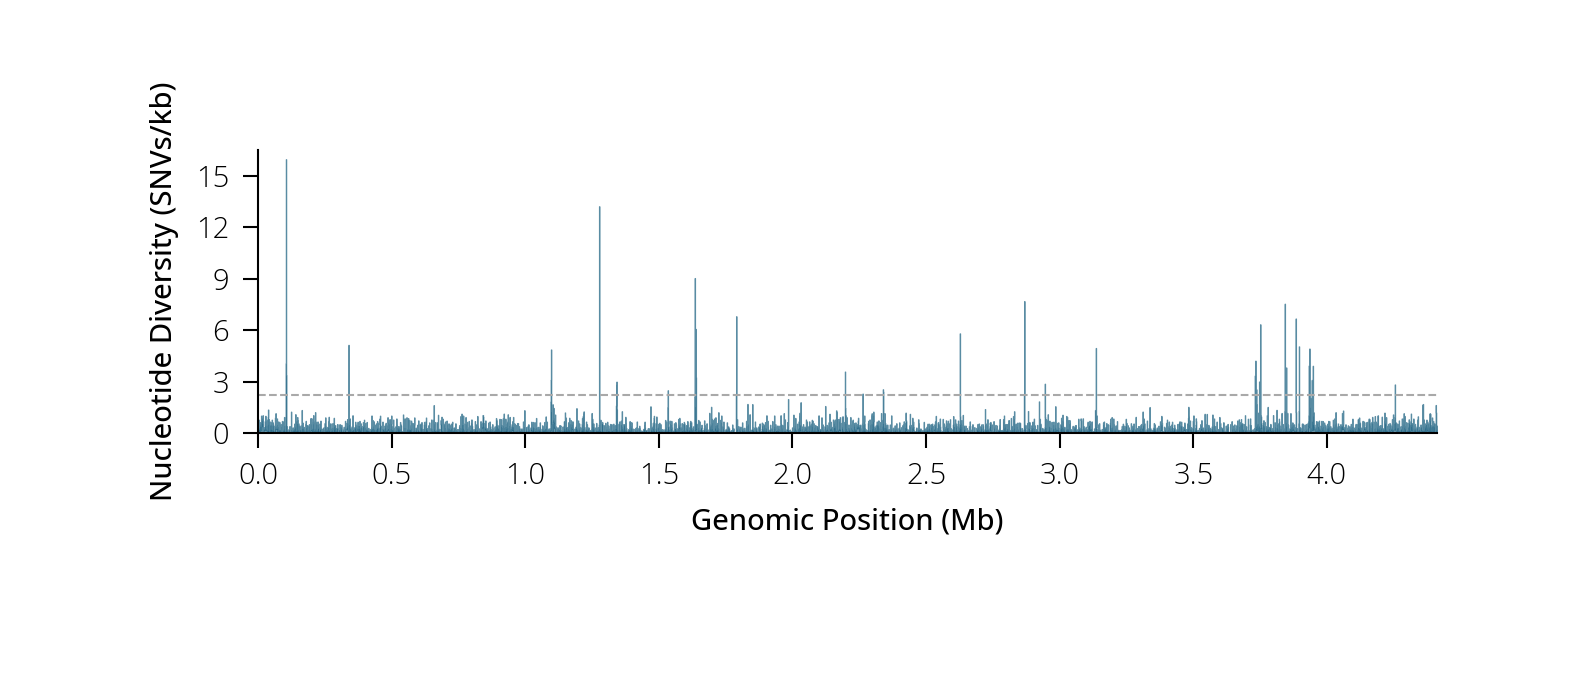

In [117]:
fig, axs = plt.subplots(1, 1, figsize=(4.5, 1.5), sharex=True)

xx_1kb_All_np = NucDiv_PI_Dict[("ALL", 1000)]["Fill_np"]["XX"]
yy_1kb_All_np = NucDiv_PI_Dict[("ALL", 1000)]["Fill_np"]["YY"] * 1000

axs.fill_between(xx_1kb_All_np, yy_1kb_All_np, color = '#065275', lw=0.3, alpha = 0.6)
axs.hlines(y= ModZ_10_NucDiv, xmin=0, xmax=5000000, color = "darkgrey", linewidth=0.5,  linestyles="--")
axs.set_xlabel('Genomic Position (Mb)', )#fontsize = 14)
axs.set_ylabel('Nucleotide Diversity (SNVs/kb)',) # fontsize = 10)
axs.set_ylim(0, 16.5)
plt.xlim(0, 4412000)

# Apply the custom formatter to the x-axis
axs.xaxis.set_major_formatter(FuncFormatter(bp_to_mb))

# Set specific tick positions and labels on the y-axis
tick_positions_y = [0, 3, 6, 9, 12, 15]
axs.set_yticks(tick_positions_y)
axs.set_yticklabels([str(tick) for tick in tick_positions_y])

sns.despine()
plt.show()

#fig.savefig('./NucDivPlots/NucDiv.1kbwindows.AcrossRv.WiLine.V1.pdf')


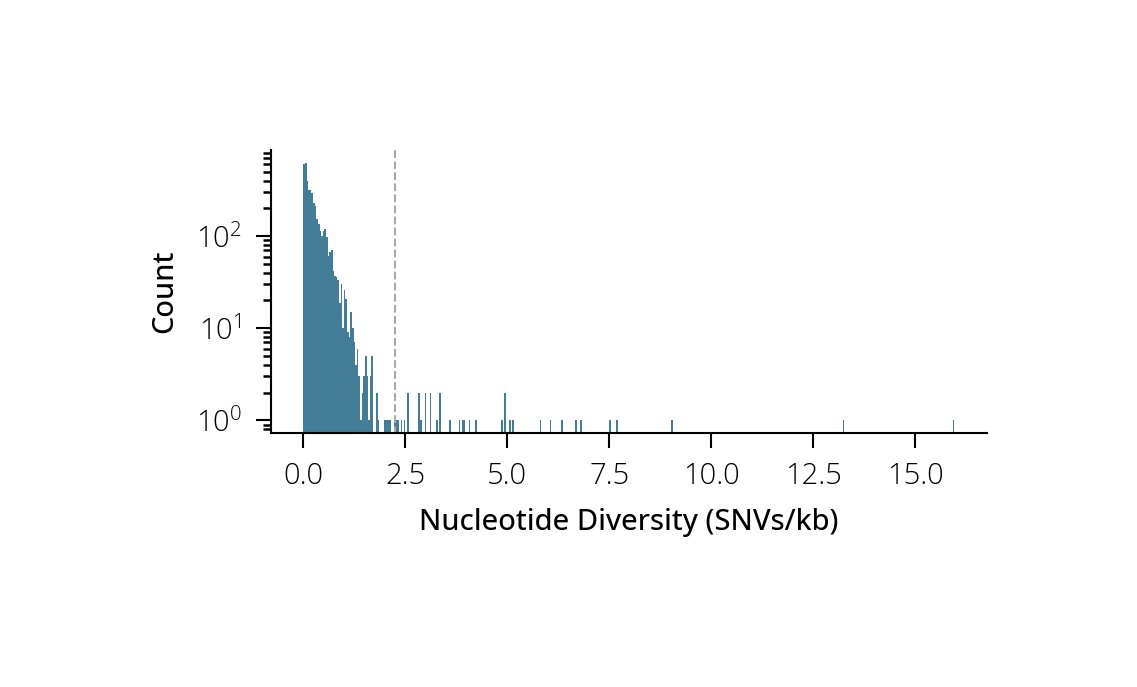

In [118]:
fig = plt.figure(figsize=(3, 1.5))

sns.histplot(WGA_NucDiv_PI_1kb_DF["NucDiv_kb"] ) #bins = np.arange(1, 18, 0.1))
plt.yscale('log')
plt.vlines(x= ModZ_10_NucDiv , ymin=0, ymax=1000,
           color = "darkgrey", linewidth=0.5,  linestyles="--")
plt.xlabel('Nucleotide Diversity (SNVs/kb)', ) #fontsize = 14)

sns.despine()
plt.show()

#fig.savefig('./NucDivPlots/NucDiv.Histogram.AcrossRv.V1.pdf')


### Histogram of NucDiv across Mtb genome

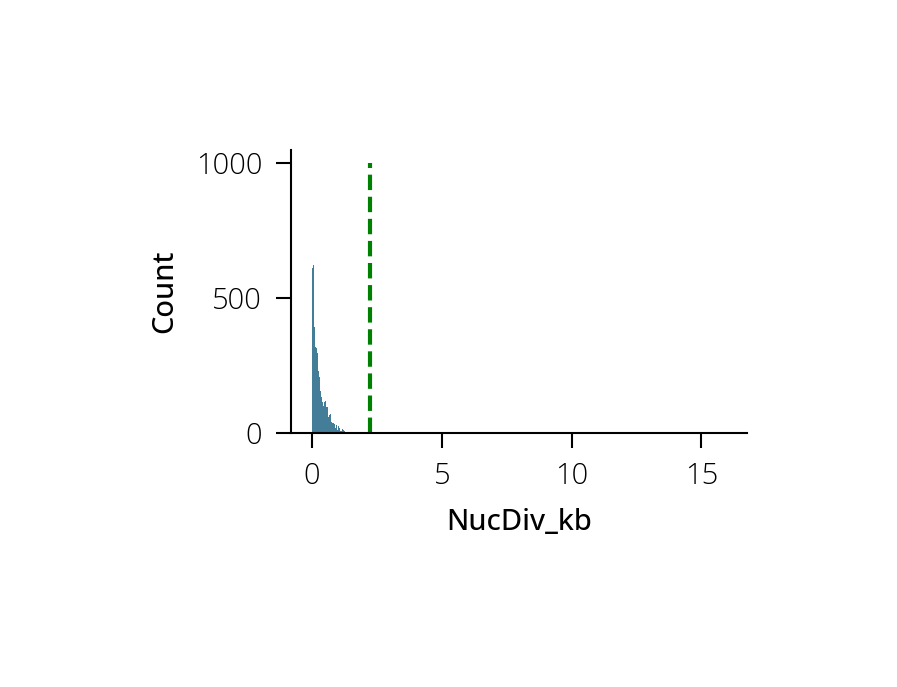

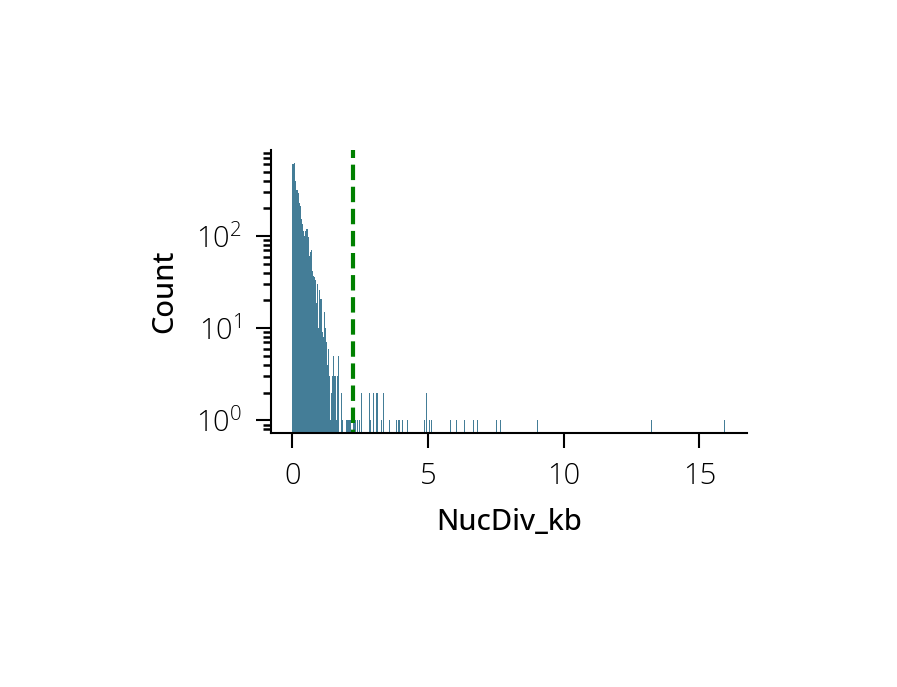

In [119]:
plt.figure(figsize=(2.2, 1.5))
sns.histplot(WGA_NucDiv_PI_1kb_DF["NucDiv_kb"], ) #bins = np.arange(1, 15000, 100))

plt.vlines(x= ModZ_10_NucDiv , ymin=0, ymax=1000,
           linewidth=1, color='g', linestyles="--")
sns.despine()
plt.show()

plt.figure(figsize=(2.2, 1.5))
sns.histplot(WGA_NucDiv_PI_1kb_DF["NucDiv_kb"], ) #bins = np.arange(1, 15000, 100))
plt.yscale('log')
plt.vlines(x= ModZ_10_NucDiv , ymin=0, ymax=1000,
           linewidth=1, color='g', linestyles="--")

sns.despine()
plt.show()


# Gene Category Breakdown - NucDiv HSs

https://www.genome.jp/kegg-bin/show_organism?org=mtu <br>
https://www.kegg.jp/kegg-bin/show_organism?org=mtv <br>
https://www.genome.jp/entry/mtu:Rv0981 <br>

### Get all GeneIDs that overlap w/ ANY NucDiv Hotspots

In [120]:
NucDiv_Hotspot_GeneIDs = []

for i, row in NucDiv_HSR_1kb_DF.iterrows():

    i_OverlapGenes = row["OverlapGenes"]

    i_listOf_OverlapGenes = i_OverlapGenes.split(",")

    NucDiv_Hotspot_GeneIDs += i_listOf_OverlapGenes
    
NucDiv_Hotspot_GeneIDs = tuple(set(NucDiv_Hotspot_GeneIDs))

print("# of GeneIDs overlapping w/ NucDiv Hotspots:", len(NucDiv_Hotspot_GeneIDs))

# of GeneIDs overlapping w/ NucDiv Hotspots: 50


In [121]:
NDHS_OverlapGeneInfo = H37Rv_GenomeAnno_Genes_DF[H37Rv_GenomeAnno_Genes_DF["Symbol"].isin(NucDiv_Hotspot_GeneIDs)]
NDHS_OverlapGeneInfo.shape

(50, 15)

In [122]:
listOfGenes_NotContributingToNucDiv = ["Rv0093c", # Next to hotspot of Rv0094c,Rv0095c
                                       "PPE1", # Next to hotspot of Rv0094c,Rv0095c
                                       "rpmF", "mprA", # Next to PE_PGRS18 hotspot
                                       "Rv1199c", # Next to hotspot of PPE18 and esxK + esxL
                                       "Rv1362c", # Next to PPE19 hotspot
                                       "Rv1453", # Next to PE_PGRS28 hotspot
                                       "Rv1586c", # Next to Rv1587c,Rv1588c hotspot 
                                       "Rv2081c", # Next to Rv2082 hotspot
                                       "Rv2348c", # Next to esxO-esxP hotspot
                                       "vapB18", # Next to lppA,lppB hotspot
                                       "Rv2827c", # Next to Rv2828c hotspot
                                       "Rv3430c", # Next to PPE59 hotspot
                                       "rmlC", # Next to Rv3466,Rv3467 hotspot
                                       "Rv3479", # Next to PPE60 hotspot
                                       "accD4"] # Next to Rv3798 hotspots 

NDHS_OverlapGeneInfo_Filt = NDHS_OverlapGeneInfo[~NDHS_OverlapGeneInfo["Symbol"].isin(listOfGenes_NotContributingToNucDiv) ]

In [123]:
NDHS_OverlapGeneInfo_Filt.shape

(34, 15)

In [124]:
NDHS_OverlapGeneInfo_Filt

,Chrom,Start,End,Strand,H37rv_GeneID,Symbol,Feature,Functional_Category,Is_Pseudogene,Product,PEandPPE_Subfamily,ExcludedGroup_Category,Gene_Cat_V2,Middle,Length
99,NC_000962.3,103709,104663,-,Rv0094c,Rv0094c,CDS,insertion seqs and phages,No,Conserved hypothetical protein,NaN,InsertionSeqs_And_Phages,REP13E12_Repeat,104186.0,954
100,NC_000962.3,104804,105215,-,Rv0095c,Rv0095c,CDS,insertion seqs and phages,No,Conserved hypothetical protein,NaN,InsertionSeqs_And_Phages,REP13E12_Repeat,105009.5,411
289,NC_000962.3,336559,339073,-,Rv0279c,PE_PGRS4,CDS,PE/PPE,No,PE-PGRS family protein PE_PGRS4,PE_V_PGRS,PE/PPEs,PE/PPE,337816.0,2514
1021,NC_000962.3,1095077,1096451,-,Rv0980c,PE_PGRS18,CDS,PE/PPE,No,PE-PGRS family protein PE_PGRS18,PE_V_PGRS,PE/PPEs,PE/PPE,1095764.0,1374
1197,NC_000962.3,1276299,1277748,-,Rv1148c,Rv1148c,CDS,insertion seqs and phages,No,Conserved hypothetical protein,NaN,InsertionSeqs_And_Phages,REP13E12_Repeat,1277023.5,1449
1246,NC_000962.3,1339348,1340524,+,Rv1196,PPE18,CDS,PE/PPE,No,PPE family protein PPE18,PPE_SL-4_PPE-SVP,PE/PPEs,PE/PPE,1339936.0,1176
1247,NC_000962.3,1340658,1340955,+,Rv1197,esxK,CDS,cell wall and cell processes,No,ESAT-6 like protein EsxK (ESAT-6 like protein 3),NaN,Coscolla Repetitive Genes,esx,1340806.5,297
1248,NC_000962.3,1341005,1341290,+,Rv1198,esxL,CDS,cell wall and cell processes,No,Putative ESAT-6 like protein EsxL (ESAT-6 like...,NaN,Coscolla Repetitive Genes,esx,1341147.5,285
1418,NC_000962.3,1532442,1533633,-,Rv1361c,PPE19,CDS,PE/PPE,No,PPE family protein PPE19,PPE_SL-4_PPE-SVP,PE/PPEs,PE/PPE,1533037.5,1191
1508,NC_000962.3,1630637,1634627,-,Rv1450c,PE_PGRS27,CDS,PE/PPE,No,PE-PGRS family protein PE_PGRS27,PE_V_PGRS,PE/PPEs,PE/PPE,1632632.0,3990


### Count frequency of gene categories in NucDiv Hotspots

In [125]:
Sub_DF = NDHS_OverlapGeneInfo_Filt

Total_DF = H37Rv_GenomeAnno_Genes_DF

column = "Gene_Cat_V2"


# Reindex to include all categories with 0 count for missing ones
Sub_category_counts = Sub_DF[column].value_counts().reindex(all_categories, fill_value=0)
Sub_category_counts_norm = Sub_DF[column].value_counts(normalize=True).reindex(all_categories, fill_value=0)
All_category_counts = Total_DF[column].value_counts().reindex(all_categories, fill_value=0)


In [126]:
Sub_category_counts

Gene_Cat_V2
PE/PPE                                     15
REP13E12_Repeat                             8
esx                                         4
conserved hypotheticals                     4
cell wall and cell processes                2
insertion seqs and phages                   1
intermediary metabolism and respiration     0
lipid metabolism                            0
information pathways                        0
virulence, detoxification, adaptation       0
regulatory proteins                         0
stable RNAs                                 0
unknown                                     0
Name: count, dtype: int64

In [127]:
Sub_category_counts_norm

Gene_Cat_V2
PE/PPE                                     0.441176
REP13E12_Repeat                            0.235294
esx                                        0.117647
conserved hypotheticals                    0.117647
cell wall and cell processes               0.058824
insertion seqs and phages                  0.029412
intermediary metabolism and respiration    0.000000
lipid metabolism                           0.000000
information pathways                       0.000000
virulence, detoxification, adaptation      0.000000
regulatory proteins                        0.000000
stable RNAs                                0.000000
unknown                                    0.000000
Name: proportion, dtype: float64

In [128]:
Sub_category_counts.sum()

34

### Plot gene categories in NucDiv Hotspots

In [129]:
!mkdir ./NucDivPlots/

mkdir: cannot create directory ‘./NucDivPlots/’: File exists


/tmp/ipykernel_410143/967730494.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=Sub_category_counts.index, x=Sub_category_counts, ax = ax1,


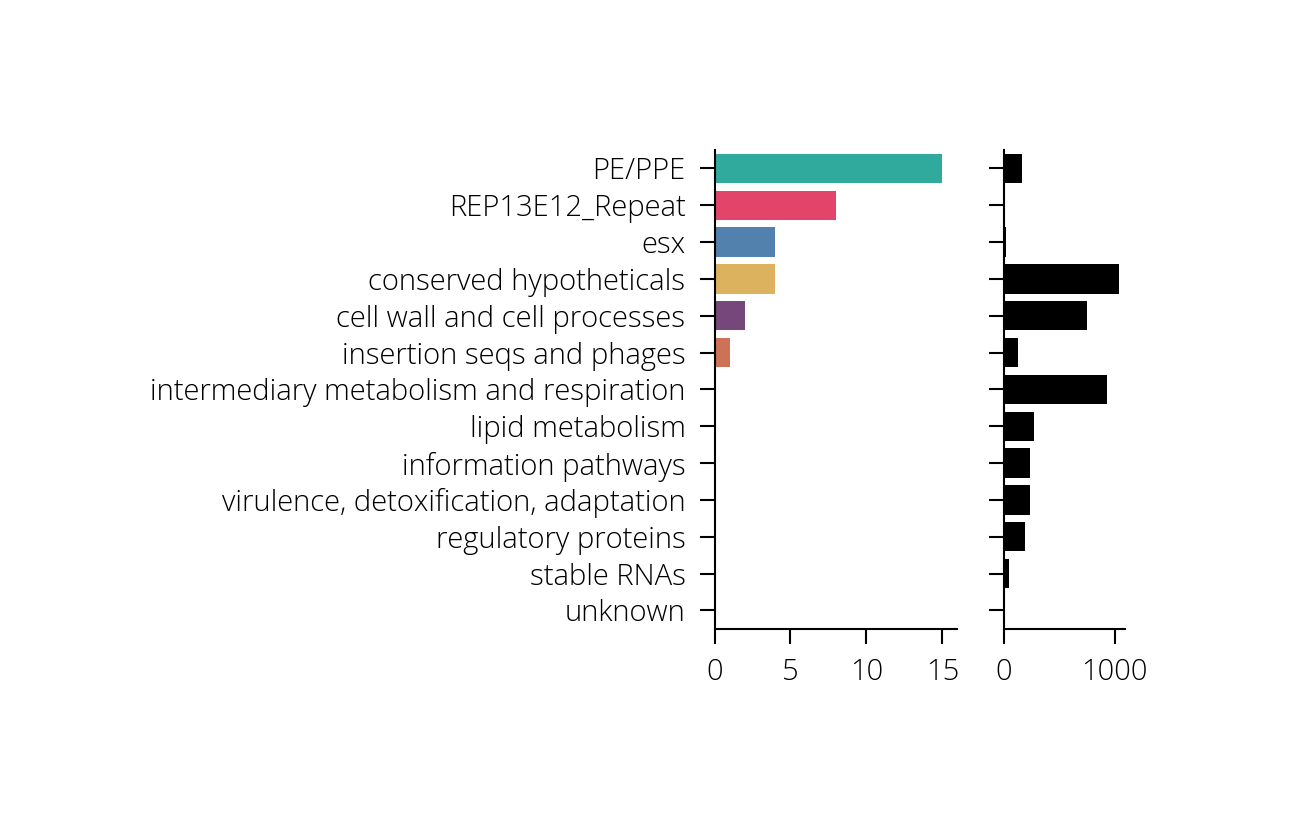

In [130]:
# Create a new figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(3.5, 2),
                               gridspec_kw={'width_ratios': [2, 1]},
                               sharey=False)

# Plot 1
#sns.barplot(y=Sub_category_counts.index, x=1, ax = ax1, color="lightgrey")
sns.barplot(y=Sub_category_counts.index, x=Sub_category_counts, ax = ax1,
            #hue = Sub_category_counts.index)
            palette = Mtb_GeneCat_ColorPallete)

ax1.set_xlim(0, 16)

# Set specific tick positions and labels on the y-axis
tick_positions_x = [0, 5, 10, 15]
ax1.set_xticks(tick_positions_x)

# Plot 2
sns.barplot(y=All_category_counts.index, x=All_category_counts, ax = ax2, color = "black")

#ax1.set_yticklabels(ax1.get_yticklabels(), fontsize=5)  # Adjust 'fontsize' as needed
#ax1.set_xticklabels(ax1.get_xticklabels(), fontsize=7)  # Adjust 'fontsize' as needed
#ax2.set_xticklabels(ax2.get_xticklabels(), fontsize=7)  # Adjust 'fontsize' as needed
ax2.set_yticklabels([])  # Adjust 'fontsize' as needed
ax1.set_ylabel('')
ax1.set_xlabel('')
ax2.set_xlabel('')
ax2.set_ylabel('')
sns.despine()
plt.tight_layout()
plt.show()

fig.savefig('./NucDivPlots/NucDiv.Hotspot.GeneCategories.V1.svg')


### Test for enrichment of gene categories

In [131]:
from scipy.stats import fisher_exact

# Create contingency tables and perform Fisher exact test for each category
results = []

for category in all_categories:
    sub_count = Sub_category_counts[category]
    total_count = All_category_counts[category]
    total_other_count = All_category_counts.sum() - total_count
    sub_other_count = Sub_category_counts.sum() - sub_count
    
    # Create the contingency table
    contingency_table = [[sub_count, total_count - sub_count],
                         [sub_other_count, total_other_count - sub_other_count]]
    
    # Perform Fisher exact test
    Stat, p_value = fisher_exact(contingency_table, alternative='greater')  # Using 'greater' to test for enrichment
    
    # Store the result
    results.append((category, Stat, p_value))

# Convert results to a DataFrame for easier viewing
results_df = pd.DataFrame(results, columns=['Category', 'Stat', 'P-value'])

# Display the results
results_df.sort_values("P-value")

,Category,Stat,P-value
1,REP13E12_Repeat,207.128205,2.791346e-14
0,PE/PPE,20.082559,8.409484e-13
2,esx,28.252632,3.187097e-05
5,insertion seqs and phages,0.898301,6.775293e-01
3,conserved hypotheticals,0.386256,9.861693e-01
4,cell wall and cell processes,0.275937,9.914596e-01
6,intermediary metabolism and respiration,0.000000,1.000000e+00
7,lipid metabolism,0.000000,1.000000e+00
8,information pathways,0.000000,1.000000e+00
9,"virulence, detoxification, adaptation",0.000000,1.000000e+00


# Plot nucleotide diversity (LINEAR) - V2 w/ Lolipops

In [132]:
NucDiv_HSR_1kb_DF

,Chrom,Start,End,Middle,OverlapGenes,NucDiv_kb,NucDiv_ModZ,IsNucDivHotspot,OvrlapWi_HmMapAln_PR,OvrlapWi_HmMapAln_LR,OvrlapWi_LowComplexityRegion,OvrlapWi_LowPmap,PLC_Mask_Ovrlap,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes
103,NC_000962.3,103000,104000,103500.0,"Rv0093c,Rv0094c",4.05131,18.817330,True,1,0,0,1,1,False,False,True,False
104,NC_000962.3,104000,105000,104500.0,"Rv0094c,Rv0095c",15.96060,76.880144,True,1,0,0,1,1,False,False,True,False
105,NC_000962.3,105000,106000,105500.0,"Rv0095c,PPE1",3.37124,15.501701,True,1,0,0,1,1,False,True,True,False
338,NC_000962.3,338000,339000,338500.0,PE_PGRS4,5.14383,24.143826,True,1,0,1,1,1,False,True,False,False
1095,NC_000962.3,1095000,1096000,1095500.0,"rpmF,PE_PGRS18",3.10016,14.180072,True,1,0,1,1,1,False,True,False,False
1096,NC_000962.3,1096000,1097000,1096500.0,"PE_PGRS18,mprA",4.87615,22.838773,True,1,0,1,1,1,False,True,False,False
1276,NC_000962.3,1276000,1277000,1276500.0,Rv1148c,13.22200,63.528313,True,1,0,0,1,1,False,False,True,False
1340,NC_000962.3,1340000,1341000,1340500.0,"PPE18,esxK",2.84020,12.912657,True,1,0,0,1,1,True,True,False,False
1341,NC_000962.3,1341000,1342000,1341500.0,"esxL,Rv1199c",2.99955,13.689556,True,1,0,0,1,1,True,False,False,False
1533,NC_000962.3,1533000,1534000,1533500.0,"PPE19,Rv1362c",2.50010,11.254526,True,1,0,0,1,1,False,True,False,False


In [133]:
NucDiv_HSR_1kb_WiCatLabels_V2_DF = NucDiv_HSR_1kb_DF.copy()

NDH_WinStart_To_FuncCat_Dict = {104000  : "REP13E12_Repeat",
                                338000  : "PE/PPE", 
                                1096000 : "PE/PPE", 
                                1276000 : "REP13E12_Repeat", 
                                1340000 : "PE/PPE", 
                                1341000 : "esx", 
                                1533000 : "PE/PPE", 
                                1634000 : "PE/PPE", 
                                1637000 : "PE/PPE", 
                                1789000 : "REP13E12_Repeat", 
                                2196000 : "REP13E12_Repeat", 
                                2262000 : "conserved hypotheticals", 
                                2338000 : "conserved hypotheticals", 
                                2626000 : "esx", 
                                2867000 : "cell wall and cell processes", 
                                2944000 : "PE/PPE", 
                                3135000 : "conserved hypotheticals", 
                                3732000 : "PE/PPE", 
                                3750000 : "PE/PPE", 
                                3842000 : "PE/PPE", 
                                3847000 : "PE/PPE", 
                                3883000 : "REP13E12_Repeat", 
                                3895000 : "PE/PPE",
                                3934000 : "PE/PPE",
                                3943000 : "PE/PPE",
                                3947000 : "PE/PPE",
                                4254000 : "insertion seqs and phages",
                                # : "",
                                }

NucDiv_HSR_1kb_WiCatLabels_V2_DF["Func_Category_Peaks"] = NucDiv_HSR_1kb_WiCatLabels_V2_DF["Start"].map(NDH_WinStart_To_FuncCat_Dict).fillna("NotPeak")

NucDiv_HSR_PeaksOnly_DF = NucDiv_HSR_1kb_WiCatLabels_V2_DF.query("Func_Category_Peaks != 'NotPeak'")
NucDiv_HSR_PeaksOnly_DF.shape


(27, 18)

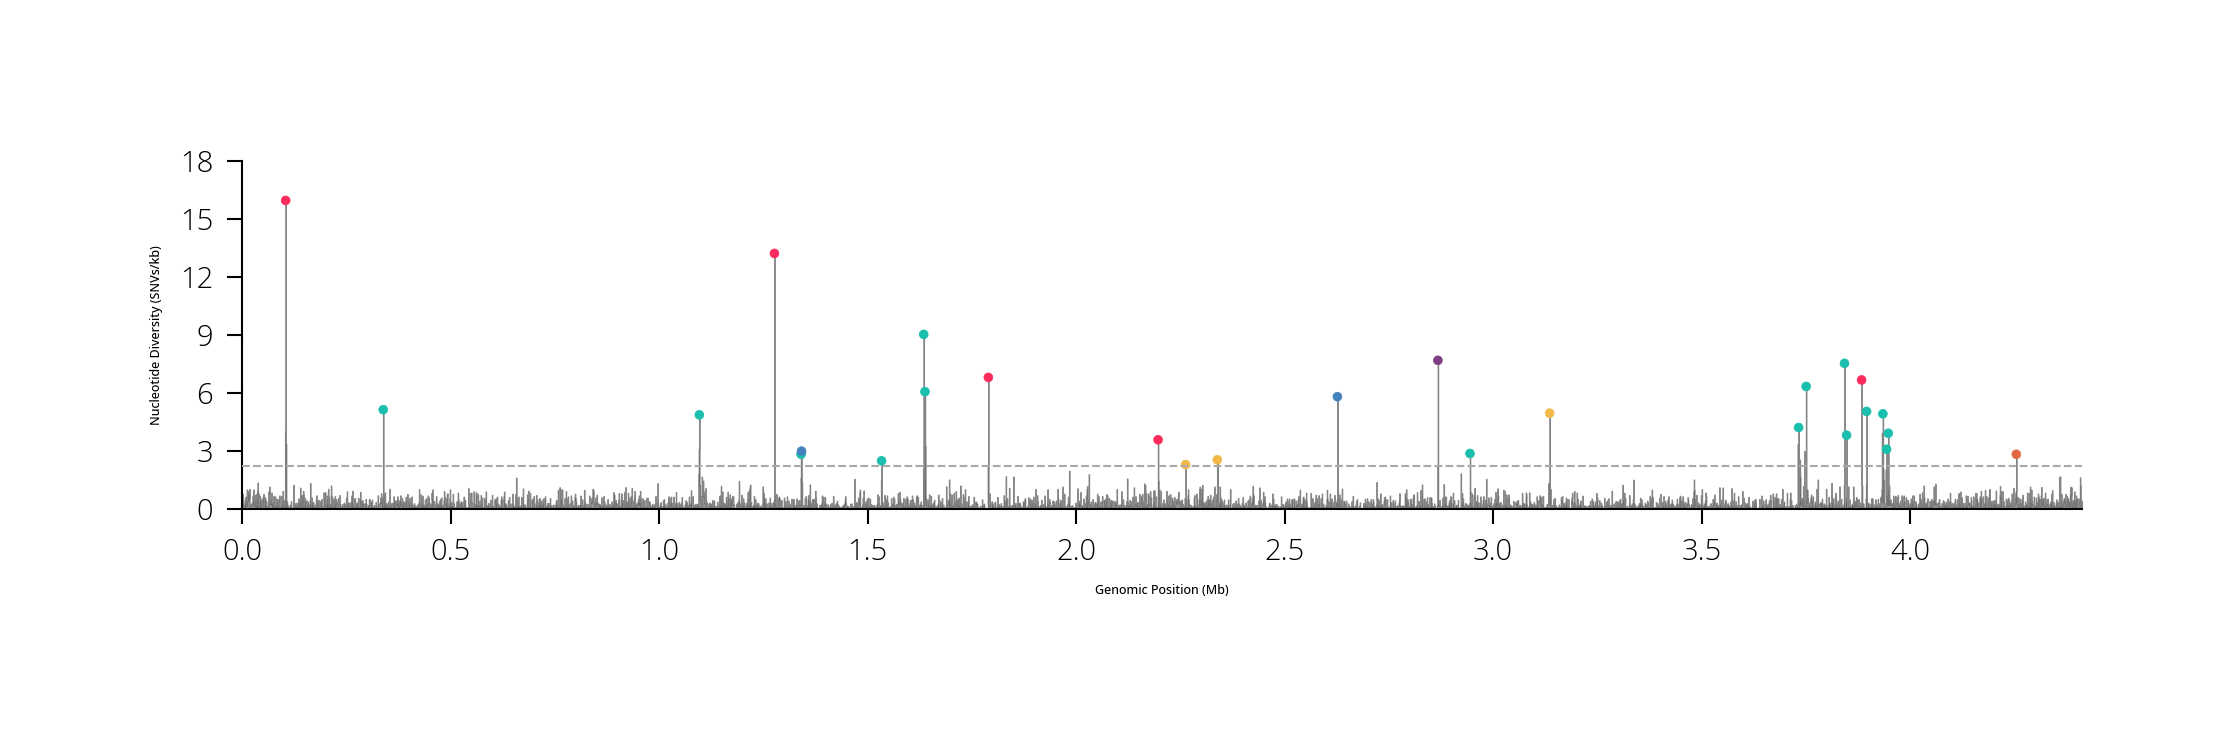

In [134]:
fig, axs = plt.subplots(1, 1, figsize=(6.65, 1.7), sharex=True)

xx_1kb_All_np = NucDiv_PI_Dict[("ALL", 1000)]["Fill_np"]["XX"]
yy_1kb_All_np = NucDiv_PI_Dict[("ALL", 1000)]["Fill_np"]["YY"] * 1000

axs.fill_between(xx_1kb_All_np, yy_1kb_All_np,
                 color = '#4E4F51',  #color = '#065275',
                 lw=0.3, alpha = 0.6)

axs.hlines(y= ModZ_10_NucDiv, xmin=0, xmax=5000000, color = "darkgrey", linewidth=0.5,  linestyles="--",
           zorder=3)

sns.scatterplot(
    x="Middle",
    y="NucDiv_kb",
    hue="Func_Category_Peaks",  # Set hue to category column
    palette=Mtb_GeneCat_ColorDict,  # Use our predefined color mapping
    data=NucDiv_HSR_PeaksOnly_DF,
    ax=axs,
    size=7,
    edgecolor="face",  # Optional: makes dots stand out
    alpha=1,  # Adjust transparency if needed
    legend=False,
    zorder=1)

axs.set_xlabel('Genomic Position (Mb)', fontsize = 3)
axs.set_ylabel('Nucleotide Diversity (SNVs/kb)', fontsize = 3)
axs.set_ylim(0, 18)
plt.xlim(0, 4412000)

# Apply the custom formatter to the x-axis
axs.xaxis.set_major_formatter(FuncFormatter(bp_to_mb))

# Set specific tick positions and labels on the y-axis
tick_positions_y = [0, 3, 6, 9, 12, 15, 18]
axs.set_yticks(tick_positions_y)
axs.set_yticklabels([str(tick) for tick in tick_positions_y])

sns.despine()
plt.tight_layout()
plt.show()


# Viz NucDiv + All Homology Links (Blue) + Hm-Link overlapping w/ NucDiv hotspot

In [135]:
NucDiv_HSR_1kb_DF.shape

(37, 17)

In [136]:
HmMap_Aln_k19w19_NoOverlap_DF.shape

(640, 38)

In [137]:
NucDiv_HSR_1kb_DF.head(1)

,Chrom,Start,End,Middle,OverlapGenes,NucDiv_kb,NucDiv_ModZ,IsNucDivHotspot,OvrlapWi_HmMapAln_PR,OvrlapWi_HmMapAln_LR,OvrlapWi_LowComplexityRegion,OvrlapWi_LowPmap,PLC_Mask_Ovrlap,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes
103,NC_000962.3,103000,104000,103500.0,"Rv0093c,Rv0094c",4.05131,18.81733,True,1,0,0,1,1,False,False,True,False


In [138]:
HmMap_Aln_k19w19_NoOverlap_DF.head(1) 

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID
0,NC_000962.3,80184,80523,+,NC_000962.3,3082465,3082769,283.0,340.0,:187+gcggctcaaccgatatcgacaaactcaccttcacct:5*tc...,0.832353,3082617.0,80353.5,1409268.5,339,304,Rv0071,Rv2774c,False,False,0,0,NC_000962.3:80184-80523,NC_000962.3:3082465-3082769,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,0,80184,80523,134,3082465,3082769,PR_HmRegion_000,PR_HmRegion_136,0,136,0,0,PR_Set_1


### Step 1: Find all Hm-Pairs that overlap w/ at least 1 NucDiv HS

In [139]:
ND_Cols = ["Chrom", "Start", "End"]
Query_Hm_Cols = ["Query_Name", "Query_Start", "Query_End"]
Target_Hm_Cols = ["Target_Name", "Target_Start", "Target_End"]
RE_CoordCols = ("seqname", "start_0based", "end_1based")

#### Count number of total variants overlapping 
HmPairs_WiAnno_DF = bf.count_overlaps(HmMap_Aln_k19w19_NoOverlap_DF,
                                      NucDiv_HSR_1kb_DF,
                                      cols1 = Query_Hm_Cols,
                                      cols2 = ND_Cols ) #cols1 = Region_CoordCols, cols2 = Var_CoordCols )

HmPairs_WiAnno_DF.rename(columns={'count': 'Query_Num_NucDivHS'}, inplace=True)


#### Count number of total variants overlapping 
HmPairs_WiAnno_DF = bf.count_overlaps(HmPairs_WiAnno_DF,
                                      NucDiv_HSR_1kb_DF,
                                      cols1 = Target_Hm_Cols,
                                      cols2 = ND_Cols ) #cols1 = Region_CoordCols, cols2 = Var_CoordCols )

HmPairs_WiAnno_DF.rename(columns={'count': 'Target_Num_NucDivHS'}, inplace=True)

HmPairs_WiAnno_DF["TargetOverlap_Genes"] = HmPairs_WiAnno_DF["TargetOverlap_Genes"].fillna("None")
HmPairs_WiAnno_DF["QueryOverlap_Genes"] = HmPairs_WiAnno_DF["QueryOverlap_Genes"].fillna("None")


In [140]:
HmPairs_WiNucDivHotspot_DF = HmPairs_WiAnno_DF.query("Query_Num_NucDivHS > 0")
HmPairs_WiNucDivHotspot_DF.shape

(72, 40)

In [141]:
HmPairs_WiDubOverlap_Hotspot_DF = HmPairs_WiAnno_DF.query("Query_Num_NucDivHS > 0 & Target_Num_NucDivHS > 0")
HmPairs_WiDubOverlap_Hotspot_DF.shape

(38, 40)

In [142]:
#GRE_ABM_WiHm_DF.head(4)

In [143]:
HmPairs_WiAnno_DF[ HmPairs_WiAnno_DF["TargetOverlap_Genes"].str.contains("PGRS45") ] 

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID,Query_Num_NucDivHS,Target_Num_NucDivHS
80,NC_000962.3,1093740,1094592,+,NC_000962.3,2944363,2945221,814.0,864.0,:11*ag*tc*ca:6*ta*tc:3*ga:2*gc:2*ca:6*ta:1-gcc...,0.942130,2944792.0,1094166.0,1850626.0,852,858,PE_PGRS17,PE_PGRS45,False,False,0,0,NC_000962.3:1093740-1094592,NC_000962.3:2944363-2945221,NC_000962.3:1093740-1094592;NC_000962.3:294436...,39,1093366,1094592,125,2944267,2945226,PR_HmRegion_040,PR_HmRegion_127,40,127,0,0,PR_Set_27,0,1
82,NC_000962.3,1095712,1096692,+,NC_000962.3,2944267,2945226,924.0,982.0,:13*cg:4*ct:7*gt*tc:7+t:1+tccaccca:1*ga:5*ct:1...,0.940937,2944746.5,1096202.0,1848544.5,980,959,PE_PGRS18,PE_PGRS45,False,False,0,0,NC_000962.3:1095712-1096692,NC_000962.3:2944267-2945226,NC_000962.3:1095712-1096692;NC_000962.3:294426...,40,1094827,1096692,125,2944267,2945226,PR_HmRegion_041,PR_HmRegion_127,41,127,0,0,PR_Set_27,2,1


In [144]:
HmPairs_WiAnno_DF[ HmPairs_WiAnno_DF["QueryOverlap_Genes"].str.contains("PGRS45") ] 

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID,Query_Num_NucDivHS,Target_Num_NucDivHS
344,NC_000962.3,2944267,2945226,+,NC_000962.3,1095712,1096692,924.0,982.0,:13*gc:4*tc:7*tg*ct:7-t:1-tccaccca:1*ag:5*tc:1...,0.940937,1096202.0,2944746.5,1848544.5,959,980,PE_PGRS45,PE_PGRS18,False,False,0,0,NC_000962.3:2944267-2945226,NC_000962.3:1095712-1096692,NC_000962.3:2944267-2945226;NC_000962.3:109571...,125,2944267,2945226,40,1095248,1096692,PR_HmRegion_127,PR_HmRegion_041,127,41,0,0,PR_Set_27,1,2
345,NC_000962.3,2944363,2945221,+,NC_000962.3,1093740,1094592,814.0,864.0,:11*ga*ct*ac:6*at*ct:3*ag:2*cg:2*ac:6*at:1+gcc...,0.942130,1094166.0,2944792.0,1850626.0,858,852,PE_PGRS45,PE_PGRS17,False,False,0,0,NC_000962.3:2944363-2945221,NC_000962.3:1093740-1094592,NC_000962.3:2944363-2945221;NC_000962.3:109374...,125,2944267,2945226,39,1093195,1094592,PR_HmRegion_127,PR_HmRegion_040,127,40,0,0,PR_Set_27,1,0


## Count how many hotspot regions with homology to another hotspot (31/37, 84%)

In [145]:
#HmPairs_WiDubOverlap_Hotspot_DF

In [146]:
NucDiv_HSR_1kb_DF.head(1)

,Chrom,Start,End,Middle,OverlapGenes,NucDiv_kb,NucDiv_ModZ,IsNucDivHotspot,OvrlapWi_HmMapAln_PR,OvrlapWi_HmMapAln_LR,OvrlapWi_LowComplexityRegion,OvrlapWi_LowPmap,PLC_Mask_Ovrlap,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes
103,NC_000962.3,103000,104000,103500.0,"Rv0093c,Rv0094c",4.05131,18.81733,True,1,0,0,1,1,False,False,True,False


In [147]:
#### Count number of total variants overlapping 
NucDiv_HSR_1kb_AnnoByHmToHS_DF = bf.count_overlaps(NucDiv_HSR_1kb_DF,
                                                   HmPairs_WiDubOverlap_Hotspot_DF, #HmPairs_WiDubOverlap_Hotspot_DF,
                                                   cols1 = ND_Cols,
                                                   cols2 = Query_Hm_Cols) #Target_Hm_Cols ) 

NucDiv_HSR_1kb_AnnoByHmToHS_DF.rename(columns={'count': 'NOvrlap_WiOtherDivHotspot'}, inplace=True)



In [148]:
NucDiv_HSR_1kb_AnnoByHmToHS_DF.shape

(37, 18)

In [149]:
NucDiv_HSR_1kb_AnnoByHmToHS_DF.query("NOvrlap_WiOtherDivHotspot > 0").shape   

(31, 18)

In [150]:
NucDiv_HSR_1kb_AnnoByHmToHS_DF.query("NOvrlap_WiOtherDivHotspot == 0").shape  

(6, 18)

In [151]:
31/37

0.8378378378378378

In [152]:
NucDiv_HSR_1kb_AnnoByHmToHS_DF.query("NOvrlap_WiOtherDivHotspot > 0")

,Chrom,Start,End,Middle,OverlapGenes,NucDiv_kb,NucDiv_ModZ,IsNucDivHotspot,OvrlapWi_HmMapAln_PR,OvrlapWi_HmMapAln_LR,OvrlapWi_LowComplexityRegion,OvrlapWi_LowPmap,PLC_Mask_Ovrlap,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,NOvrlap_WiOtherDivHotspot
0,NC_000962.3,103000,104000,103500.0,"Rv0093c,Rv0094c",4.05131,18.817330,True,1,0,0,1,1,False,False,True,False,2
1,NC_000962.3,104000,105000,104500.0,"Rv0094c,Rv0095c",15.96060,76.880144,True,1,0,0,1,1,False,False,True,False,2
2,NC_000962.3,105000,106000,105500.0,"Rv0095c,PPE1",3.37124,15.501701,True,1,0,0,1,1,False,True,True,False,2
4,NC_000962.3,1095000,1096000,1095500.0,"rpmF,PE_PGRS18",3.10016,14.180072,True,1,0,1,1,1,False,True,False,False,1
5,NC_000962.3,1096000,1097000,1096500.0,"PE_PGRS18,mprA",4.87615,22.838773,True,1,0,1,1,1,False,True,False,False,1
6,NC_000962.3,1276000,1277000,1276500.0,Rv1148c,13.22200,63.528313,True,1,0,0,1,1,False,False,True,False,1
7,NC_000962.3,1340000,1341000,1340500.0,"PPE18,esxK",2.84020,12.912657,True,1,0,0,1,1,True,True,False,False,3
8,NC_000962.3,1341000,1342000,1341500.0,"esxL,Rv1199c",2.99955,13.689556,True,1,0,0,1,1,True,False,False,False,1
9,NC_000962.3,1533000,1534000,1533500.0,"PPE19,Rv1362c",2.50010,11.254526,True,1,0,0,1,1,False,True,False,False,2
10,NC_000962.3,1634000,1635000,1634500.0,PE_PGRS27,9.03773,43.128231,True,1,0,1,1,1,False,True,False,False,1


In [153]:
NucDiv_HSR_1kb_AnnoByHmToHS_DF.query("NOvrlap_WiOtherDivHotspot == 0")

,Chrom,Start,End,Middle,OverlapGenes,NucDiv_kb,NucDiv_ModZ,IsNucDivHotspot,OvrlapWi_HmMapAln_PR,OvrlapWi_HmMapAln_LR,OvrlapWi_LowComplexityRegion,OvrlapWi_LowPmap,PLC_Mask_Ovrlap,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,NOvrlap_WiOtherDivHotspot
3,NC_000962.3,338000,339000,338500.0,PE_PGRS4,5.14383,24.143826,True,1,0,1,1,1,False,True,False,False,0
16,NC_000962.3,2262000,2263000,2262500.0,Rv2015c,2.30490,10.302844,True,1,0,0,1,1,False,False,False,True,0
17,NC_000962.3,2338000,2339000,2338500.0,"Rv2081c,Rv2082",2.55567,11.525454,True,1,0,1,1,1,False,False,False,True,0
18,NC_000962.3,2339000,2340000,2339500.0,Rv2082,2.40884,10.809595,True,0,0,0,1,1,False,False,False,True,0
22,NC_000962.3,3135000,3136000,3135500.0,"Rv2827c,Rv2828c",4.96200,23.257328,True,1,0,0,1,1,False,False,False,True,0
36,NC_000962.3,4254000,4255000,4254500.0,"Rv3798,accD4",2.83769,12.900420,True,1,0,0,1,1,False,False,False,True,0


In [154]:
NucDiv_HSR_1kb_AnnoByHmToHS_DF.head(4)

,Chrom,Start,End,Middle,OverlapGenes,NucDiv_kb,NucDiv_ModZ,IsNucDivHotspot,OvrlapWi_HmMapAln_PR,OvrlapWi_HmMapAln_LR,OvrlapWi_LowComplexityRegion,OvrlapWi_LowPmap,PLC_Mask_Ovrlap,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,NOvrlap_WiOtherDivHotspot
0,NC_000962.3,103000,104000,103500.0,"Rv0093c,Rv0094c",4.05131,18.817330,True,1,0,0,1,1,False,False,True,False,2
1,NC_000962.3,104000,105000,104500.0,"Rv0094c,Rv0095c",15.96060,76.880144,True,1,0,0,1,1,False,False,True,False,2
2,NC_000962.3,105000,106000,105500.0,"Rv0095c,PPE1",3.37124,15.501701,True,1,0,0,1,1,False,True,True,False,2
3,NC_000962.3,338000,339000,338500.0,PE_PGRS4,5.14383,24.143826,True,1,0,1,1,1,False,True,False,False,0


## Circular NucDiv plot - V3 

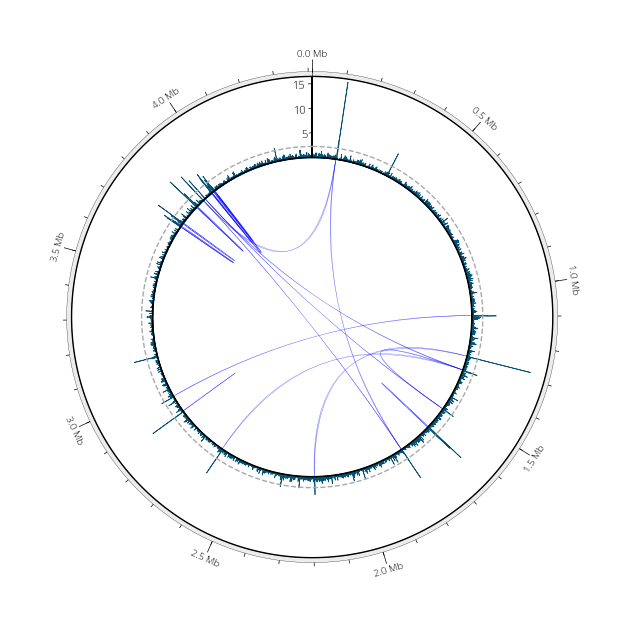

In [155]:
# main fig params
color_dict = {'nucdiv': '#065275',
              'events': '#39618C',
              'arcs': '#F6605E',
              'hm_arcs': "gray",
              'scale_track': '#edebeb'}

circos = Circos(sectors={"NC_000962.3": 4411532}, endspace=False)
#circos.text("M. tuberculosis Genome \n(H37Rv, NC_000962)", size=12, r=20)
sector = circos.get_sector("NC_000962.3")

## SCALE TRACK
major_ticks_interval, minor_ticks_interval = 500000, 100000
scale_track = sector.add_track((98, 100))

# background color and line
scale_track.axis(fc=color_dict['scale_track'], 
                 lw=0.2)

# ticks
scale_track.xticks_by_interval(major_ticks_interval, 
                               label_size=7, 
                               tick_length=5, 
                               outer=True,
                               show_bottom_line=False,
                               label_orientation='horizontal',
                               line_kws=dict(ec='black'),
                               label_formatter=lambda v: f"{v/ 10 ** 6:.1f} Mb")

scale_track.xticks_by_interval(minor_ticks_interval, 
                               tick_length=1.5, 
                               show_label=False)
#####################

xaxis_track1 = sector.add_track((65, 65.1))
xaxis_track1.axis()

track1 = sector.add_track((65, 98), )#r_pad_ratio=0.1)
track1.axis(lw=1)

track1.fill_between(xx_1kb_All_np[:-19], yy_1kb_All_np[:-19], alpha=1, 
                    lw= 0.5,
                    vmax = 16.5,
                    color = color_dict['nucdiv'], label = "Nucleotide Diversity (SNP)",)

track1.line([0, 4411532], [ModZ_10_NucDiv , ModZ_10_NucDiv],
            vmax = 16.5,
            lw=1, ls="dashed", color = "darkgrey")


y = [5, 10, 15]
y_labels = ["5", "10", "15",] 
track1.yticks(y, y_labels,
              vmax = 16.5, 
              side = "left",
              label_size = 8)

#### Draw links of homology map alignments that overlap w/ a ####
for i, row in HmPairs_WiDubOverlap_Hotspot_DF.iterrows():
    i_region1 = (row["Query_Name"], row["Query_Start"] - 250, row["Query_End"] + 250)
    i_region2 = (row["Target_Name"], row["Target_Start"] - 250, row["Target_End"] + 250)
    circos.link(i_region1,
                i_region2,
                color="blue", direction = 1, alpha = 0.5)
##########################################



fig = circos.plotfig(figsize = (5.5, 5.5))

# Add legend
handles = [
    Patch(color = color_dict['nucdiv'], label="Nucleotide Diversity (SNPs\kb)"),
    Patch(color = "blue", label="Pairs of diversity hotspots with detected homology"),
]

#_ = circos.ax.legend(handles=handles, bbox_to_anchor=(1.5, 1), loc="right", fontsize=10)

#fig.savefig('./NucDivPlots/NucDiv.1kbwindows.Circos.WiHomologyLinks.V2.pdf')


In [156]:
ModZ_10_NucDiv

2.2427835218680507

In [157]:
np.max(yy_1kb_All_np ) #* 1000)

15.960599999999998

In [158]:
np.max(yy_1kb_All_np)

15.960599999999998

In [159]:
HmPairs_WiDubOverlap_Hotspot_DF["QueryOverlap_Genes"].nunique()

28

In [160]:
HmPairs_WiDubOverlap_Hotspot_DF["TargetOverlap_Genes"].nunique()

28

## Circular NucDiv plot - V4

In [ ]:
# main fig params
color_dict = {'nucdiv': '#4E4F51',
              'events': '#39618C',
              'arcs': '#F6605E',
              'hm_arcs': "gray",
              'scale_track': '#edebeb'}

circos = Circos(sectors={"NC_000962.3": 4411532}, endspace=False)
#circos.text("M. tuberculosis Genome \n(H37Rv, NC_000962)", size=12, r=20)
sector = circos.get_sector("NC_000962.3")

## SCALE TRACK
major_ticks_interval, minor_ticks_interval = 500000, 100000
scale_track = sector.add_track((98, 100))

# background color and line
scale_track.axis(fc=color_dict['scale_track'], 
                 lw=0.2)

# ticks
scale_track.xticks_by_interval(major_ticks_interval, 
                               label_size=12, 
                               tick_length=5, 
                               outer=True,
                               show_bottom_line=False,
                               label_orientation='horizontal',
                               line_kws=dict(ec='black'),
                               label_formatter=lambda v: f"{v/ 10 ** 6:.1f} Mb")

scale_track.xticks_by_interval(minor_ticks_interval, 
                               tick_length=1.5, 
                               show_label=False)
#####################

xaxis_track1 = sector.add_track((65, 65.1))
xaxis_track1.axis()

track1 = sector.add_track((65, 98), ) #r_pad_ratio=0.1)
track1.axis(lw=1)

track1.line(xx_1kb_All_np[:-19], yy_1kb_All_np[:-19],
            alpha=1, 
            lw= 0.5,
            vmax = 18,
            color = color_dict['nucdiv'],
            label = "Nucleotide Diversity (SNVs\kb)",)


track1.line([0, 4411532], [ModZ_10_NucDiv, ModZ_10_NucDiv],
            vmax = 17.5,
            lw=1, ls="dashed", color = "darkgrey")

NDHS_Pos = NucDiv_HSR_PeaksOnly_DF["Middle"].values
NDHS_NucDiv = NucDiv_HSR_PeaksOnly_DF["NucDiv_kb"].values

NDHS_Colors = NucDiv_HSR_PeaksOnly_DF['Func_Category_Peaks'].map(Mtb_GeneCat_ColorDict)


track1.scatter(np.array(NDHS_Pos),
                     np.array( NDHS_NucDiv),
                     vmax = 18,
                     color = NDHS_Colors,
                     s = 20,
                     marker='o',)

y = [5, 10, 15]
y_labels = ["5", "10", "15",] 
track1.yticks(y, y_labels,
              vmax = 16.5, 
              side = "left",
              label_size = 8)


#### Draw links of homology map alignments that overlap w/ a ####
for i, row in HmPairs_WiDubOverlap_Hotspot_DF.iterrows():
    i_region1 = (row["Query_Name"], row["Query_Start"] - 250, row["Query_End"] + 250)
    i_region2 = (row["Target_Name"], row["Target_Start"] - 250, row["Target_End"] + 250)
    circos.link(i_region1,
                i_region2,
                color="blue", direction = 1, alpha = 0.5)




fig = circos.plotfig(figsize = (10, 10))

# Add legend
handles = [
    Patch(color = color_dict['nucdiv'], label="Nucleotide Diversity (SNVs\kb)"),
    #Patch(color = "blue", label="Pairs of diversity hotspots with detected homology"),
]

#_ = circos.ax.legend(handles=handles, bbox_to_anchor=(1.5, 1), loc="right", fontsize=10)

fig.savefig('./NucDivPlots/NucDiv.1kbwindows.Circos.WiHomologyLinks.V1.pdf')
fig.savefig('./NucDivPlots/NucDiv.1kbwindows.Circos.WiHomologyLinks.V1.svg')


## Viz linear view of NucDiv + links between homologous regions

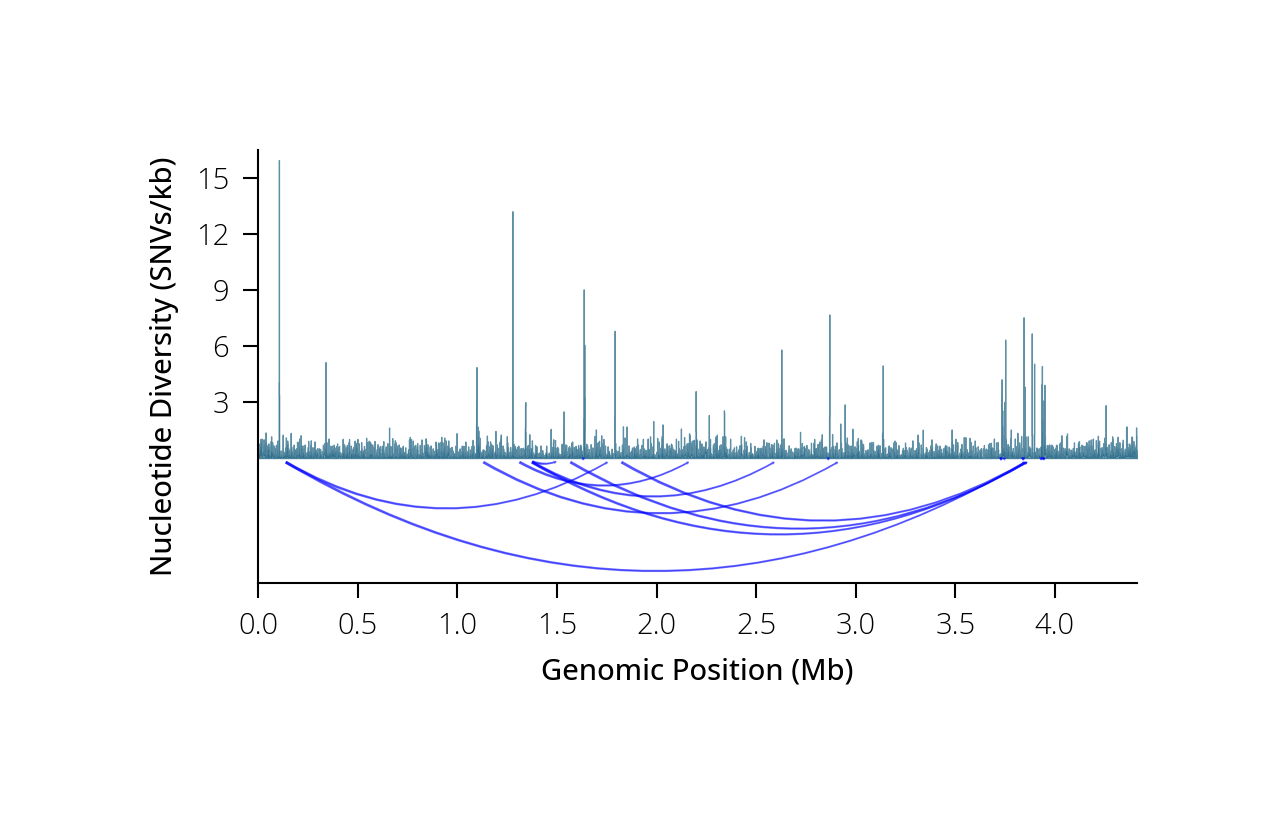

In [162]:
fig, axs = plt.subplots(1, 1, figsize=(3.5, 2), sharex=True)

xx_1kb_All_np = NucDiv_PI_Dict[("ALL", 1000)]["Fill_np"]["XX"]
yy_1kb_All_np = NucDiv_PI_Dict[("ALL", 1000)]["Fill_np"]["YY"] * 1000

axs.fill_between(xx_1kb_All_np, yy_1kb_All_np, color = '#065275', lw=0.3, alpha = 0.6)
axs.hlines(y= ModZ_10_NucDiv * 1000, xmin=0, xmax=5000000, color = "darkgrey", linewidth=0.5,  linestyles="--")
axs.set_xlabel('Genomic Position (Mb)', )#fontsize = 14)
axs.set_ylabel('Nucleotide Diversity (SNVs/kb)',) # fontsize = 10)
axs.set_ylim(-6.7, 16.5)
plt.xlim(0, 4412000)

# Apply the custom formatter to the x-axis
axs.xaxis.set_major_formatter(FuncFormatter(bp_to_mb))

# Set specific tick positions and labels on the y-axis
tick_positions_y = [3, 6, 9, 12, 15 ]
axs.set_yticks(tick_positions_y)
axs.set_yticklabels([str(tick) for tick in tick_positions_y])

# Draw RED arcs for all homology pairs overlapping w/ a NucDiv hotspots

for i, row in HmPairs_WiDubOverlap_Hotspot_DF.iterrows():

    query_Mid = row["Query_Middle"]
    target_Mid = row["Target_Middle"]

    hm_arc = FancyArrowPatch( (np.min([query_Mid, target_Mid]), 0), 
                              (np.max([query_Mid, target_Mid]), 0),
                              connectionstyle="arc3,rad=.3",
                              arrowstyle = "Fancy",
                              color="blue", linewidth=0.3, alpha=0.3)
    axs.add_patch(hm_arc)

sns.despine()
plt.show()


fig.savefig('./NucDivPlots/NucDiv.1kbwindows.AcrossRv.WiLine.WiArcs.V1.pdf')
